Script to post-process timer outputs
on cooling energy and cooling gap

In [1]:
# import packages 
import os
import pandas as pd
import pym
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import ticker
import matplotlib.ticker as mticker  
from matplotlib.ticker import MaxNLocator
import math
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

In [2]:
# define and set directories

MAIN_DIR = r'X:/user/crassierc'
IMAGE_REGION_MAPPING_DIR = os.path.join(MAIN_DIR, r'code\geospatial-metadata\mappings')
FIG_DIR = os.path.join(MAIN_DIR, r'code/cooling/CoolingGap/figures/')

# change user directory depending on outputs location
MAIN_DIR_USER = 'crassierc'

MAIN_DIR = f'X:/user/{MAIN_DIR_USER}'
if MAIN_DIR_USER == 'crassierc':
    OUTPUT_DIR = os.path.join(MAIN_DIR, r'Projects\PRISMA\2_TIMER\outputlib\TIMER_3_4\PRISMA')
elif MAIN_DIR_USER == 'dekkerm':
    OUTPUT_DIR = os.path.join(MAIN_DIR, r'IMAGE_environments\IMPACTS\2_TIMER\outputlib\TIMER_3_4\IMPACTS')

RESIDENTIAL_DIR = os.path.join(OUTPUT_DIR, r'{}\T2RT\endem\residential')
TUSS_RES_DIR = os.path.join(OUTPUT_DIR, r'{}\tuss\endem\residential')
EMIS_DIR = os.path.join(OUTPUT_DIR, r'{}\tuss\emis')
COOLING_GAP_DIR = os.path.join(OUTPUT_DIR, r'{}\T2RT\cooling_gap')
GMT_DIR = os.path.join(OUTPUT_DIR, r'{}\indicators\Climate')

os.chdir(MAIN_DIR)

In [3]:
# load timer output data
appliance_diffusion_fp = os.path.join(TUSS_RES_DIR, 'res_diffusion.out')          # [27,13,11]
energy_use_fp = os.path.join(RESIDENTIAL_DIR, 'ApplEnUse.out')                        # [27,13,11] 
heat_exposed_share_fp = os.path.join(COOLING_GAP_DIR, 'exposed_pop_heat_share.out')   # [26,4]: take median of the the second dimension
heat_exposed_pop_fp = os.path.join(COOLING_GAP_DIR, 'exposed_pop_heat.out')
heat_exposed_pop_per_threshold_fp = os.path.join(COOLING_GAP_DIR, 'exposed_pop_heat_per_threshold.out')
cooling_gap_pop_fp = os.path.join(COOLING_GAP_DIR, 'cooling_gap_pop.out')             # [27,13,3]
cooling_gap_share_fp = os.path.join(COOLING_GAP_DIR, 'cooling_gap_share.out')             # [27,13,3]
appliance_saturation_fp = os.path.join(COOLING_GAP_DIR, 'saturation_cooling.out')
pop_fp = os.path.join(OUTPUT_DIR, r'{}\indicators\endem\residential\Pop_q.out')                              # regional population
heating_fp = os.path.join(OUTPUT_DIR, r'{}\indicators\endem\residential\res_UESpaceheating.out')  # heating energy use
heating_2_fp = os.path.join(OUTPUT_DIR, r'{}\T2RT\engen\final_energy_buildings_heating.out')  # heating energy use (residential,commercial,total)
CO2_emis_fp = os.path.join(EMIS_DIR, 'CO2Spec2.out')
private_consumption_fp = os.path.join(TUSS_RES_DIR, 'res_pppPCOpc.out')
gmt_fp = os.path.join(GMT_DIR, 'Temp_EST.out')
appliance_access_fp = os.path.join(RESIDENTIAL_DIR, 'res_ApplianceAccess.out')
households_fp = os.path.join(RESIDENTIAL_DIR, 'Households.out')
household_size_fp = os.path.join(RESIDENTIAL_DIR, 'res_HouseholdSize.out')
cdd_for_reporting_fp = os.path.join(COOLING_GAP_DIR, r'CDD_for_reporting.out')
cdd_fp = os.path.join(COOLING_GAP_DIR, r'CDD.out')

scenarios = [
    # multi-model mean scenarios
    'SSP2_MM',
    'SSP2_NO_GAP_ELEC_MM',
    'SSP2_20D_MM',
    'SSP2_NO_GAP_ELEC_20D_MM',
    'SSP2_NO_GAP_ELEC_SUST_20D_MM',
   #  'SSP1_MM',
   #  'SSP1_NO_GAP_ELEC_MM',
   #  'SSP1_20D_MM',
   #  'SSP1_NO_GAP_ELEC_20D_MM',
   #  'SSP1_NO_GAP_ELEC_SUST_20D_MM', 
   #  'SSP3_MM',
   #  'SSP3_NO_GAP_ELEC_MM',
   #  'SSP5_MM',
   #  'SSP5_NO_GAP_ELEC_MM',
   #  'SSP2_NO_UHI_MM',
   #  'SSP2_RELATIVE_UHI_MM',
   #  'SSP2_20D_RELATIVE_UHI_MM',

    # multi-model mean scenarios but with UHI effect represented with relative factor on DDs - using these to compare CDD results with IPSL scenarios
   #  'SSP2_MMM',
   #  'SSP2_NO_GAP_ELEC_MMM',
   #  'SSP2_20D_MMM',
   #  'SSP2_NO_GAP_ELEC_20D_MMM',
   #  'SSP2_NO_GAP_ELEC_SUST_20D_MMM',

   # IPSL scenarios
   #  'SSP2_IPSL',
   #  'SSP2_NO_GAP_ELEC_IPSL',
   #  'SSP2_20D_IPSL',
   #  'SSP2_NO_GAP_ELEC_20D_IPSL',
   #  'SSP2_NO_GAP_ELEC_SUST_20D_IPSL'
   
    # SPARRCLE SCENARIOS
   #  'IMP-SSP2-REF-noGDPIMP-15',
   #  'IMP-SSP3-REF-noGDPIMP-15',
   #  'IMP-SSP2-REF-GDPIMP-15',
   #  'IMP-SSP3-REF-GDPIMP-15',
   #   'IMP-SSP2-REF-noGDPIMP-CP'
]
filepaths = {
   'appliance_diffusion': appliance_diffusion_fp,
   'energy_use': energy_use_fp,
   'heat_exposed_share': heat_exposed_share_fp,
   'heat_exposed_pop': heat_exposed_pop_fp,
   'heat_exposed_pop_per_threshold': heat_exposed_pop_per_threshold_fp,
   'cooling_gap_pop': cooling_gap_pop_fp,
   'cooling_gap_pop_share': cooling_gap_share_fp,
   'appliance_saturation': appliance_saturation_fp,
   'pop': pop_fp,
   'emis' : CO2_emis_fp,
   'private_consumption': private_consumption_fp,
   'gmt': gmt_fp,
   'heating_energy_use': heating_fp,
   'heating_2_energy_use': heating_2_fp,
   'appliance_access': appliance_access_fp,
   'households': households_fp,
   'household_size': household_size_fp,
   'cdd_for_reporting': cdd_for_reporting_fp,
   # 'cdd': cdd_fp   # ignore because not needed in my paper, used to check non-scaled CDD values

} 

# load image region mapping data
region_mapping_fp = os.path.join(IMAGE_REGION_MAPPING_DIR, r'country_to_regions.csv')
region_numbers_fp = os.path.join(IMAGE_REGION_MAPPING_DIR, r'image_region_numbers.csv')

region_mapping = pd.read_csv(region_mapping_fp, encoding='latin-1')
region_numbers = pd.read_csv(region_numbers_fp)

In [4]:
# load mym output file as array of tuples
def load_files(fp):
    file = pym.read_mym(fp)
    return file

# convert tuple data into xarray dataarray
def create_dataarray(data_tuple):

    data, years = data_tuple
    shape = data.shape
    
    dims = ['year']
    coords = {'year': years}
    dim_names = ['region', 'dim2', 'dim3', 'dim4']
    
    for i, dim_size in enumerate(shape[1:]):
        if i < len(dim_names):
            dim_name = dim_names[i]
            dims.append(dim_name)
            coords[dim_name] = list(range(dim_size))

    da = xr.DataArray(
        data=data,
        dims=dims,
        coords=coords
    )
    
    return da

In [5]:
# loads data and converts to dataarrays
def load_data_as_arrays(filepaths, scenarios):
    result = {}

    for scenario in scenarios:
        result[scenario] = {}

        for name, path_template in filepaths.items():
            formatted_path = path_template.format(scenario)
            data_tuple = load_files(formatted_path)
            result[scenario][name] = create_dataarray(data_tuple)
            
    return result

all_data = load_data_as_arrays(filepaths, scenarios)

In [12]:
GREY20 = "#333333"

**FIGURES**

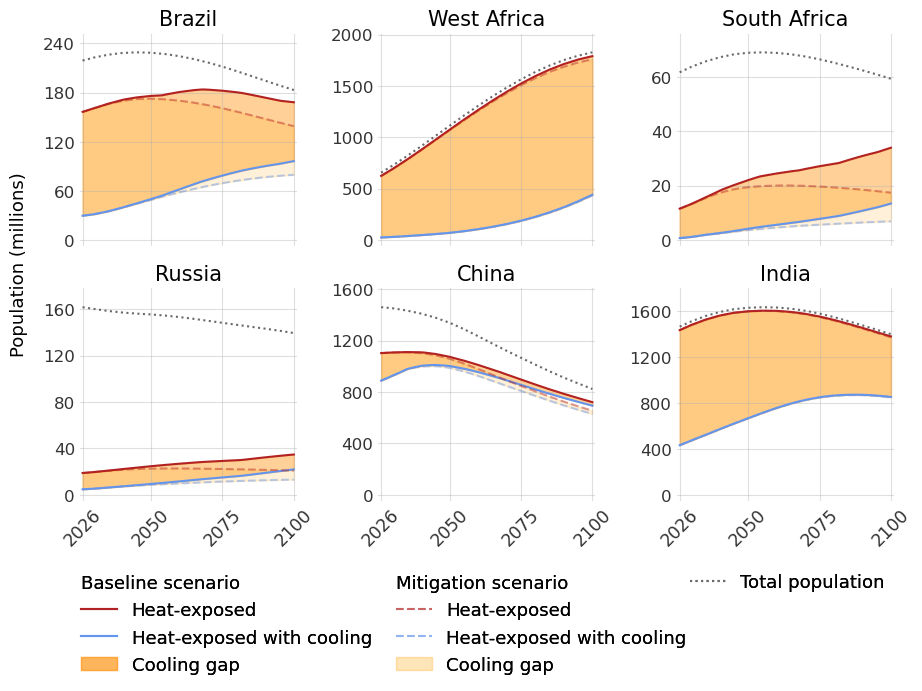

In [70]:
def regional_cooling_gap_plot(ax, years, scens, exposed_pop, exposed_with_cooling, total_pop, region):

    ax.plot(years, exposed_pop[scens[0]], color='firebrick', label='Heat-exposed')
    ax.plot(years, exposed_with_cooling[scens[0]],
            color='cornflowerblue', label='Heat-exposed with cooling')    
    ax.fill_between(years, exposed_pop[scens[0]], exposed_with_cooling[scens[0]],
                    interpolate=True, color='darkorange', alpha=0.4, label='Cooling gap')
    
    ax.plot(years, exposed_pop[scens[1]], color='firebrick', linestyle='--', label='Heat-exposed', alpha=0.45)
    ax.plot(years, exposed_with_cooling[scens[1]],
            color='cornflowerblue', label='Heat-exposed with cooling', linestyle='--', alpha=0.45)
    ax.fill_between(years, exposed_pop[scens[1]], exposed_with_cooling[scens[1]],
                    interpolate=False, color='orange', alpha=0.15, label='Cooling gap')
    
    ax.plot(years, total_pop, color='dimgrey', linestyle='dotted', label='Total population')

    xticks = [2026, 2050, 2075, 2100]
    if i > 0:
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, color=GREY20, fontsize=12.5)
    elif i == 0:
        ax.set_xticks([])
    
    ax.tick_params(axis='x', labelrotation=45)
    ax.yaxis.set_major_formatter(
        ticker.FormatStrFormatter('%0.0f'))
    for label in ax.get_yticklabels():
        label.set_color(GREY20)
        label.set_fontsize(12)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    
    ax.yaxis.set_tick_params(which="both", length=0)
    ax.xaxis.set_tick_params(which="both", length=0)
    
    ax.set_xlim(2025, 2101)
    ax.set_ylim(-3e-2*region_max, 1.1*region_max)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(which="major", lw=0.8, alpha=0.4)
    ax.set_title(region, color='black', fontsize=15)

region_names = ['Brazil', 'West Africa', 'South Africa', 'Russia', 'China', 'India']
regions_list = [4, 7, 9, 15, 19, 17]
n_regions = len(regions_list)
cols = min(3, n_regions)
rows = (n_regions + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(9, 6), sharex=True)
axes = axes.flatten()

scenarios = ['SSP2_MM', 'SSP2_20D_MM']
for i, region in enumerate(regions_list):
    ax = axes[i]
    years = np.arange(2026, 2101)

    total_pop = all_data[scenarios[0]]['pop'].sel(
         year=years, region=region, dim2=0) / 1e6

    exposed_pop = {}
    exposed_with_cooling = {}
    
    for scen in scenarios:
        filtered_data = all_data[scen]
        
        exposed_pop[scen] = filtered_data['heat_exposed_pop'].sel(
         year=years, region=region, dim2=0) / 1e6

        exposed_with_cooling[scen] = 0
        quintiles = list(range(3,12))
        for quintile in quintiles:
                heat_exposed_per_quintile = filtered_data['heat_exposed_pop'].sel(
                    year=years, region=region, dim2=quintile)
                appliance_ability_per_quintile = filtered_data['appliance_diffusion'].sel(
                    year=years, region=region, dim2=quintile, dim3=slice(1,2)
                    ).sum('dim3') / (
                         filtered_data['appliance_saturation'].sel(
                    year=years, region=region, dim2=quintile, dim3=slice(1,2)
                    ).sum('dim3'))
                exposed_with_cooling_per_quintile = (
                    heat_exposed_per_quintile -
                    heat_exposed_per_quintile * (
                        1 - appliance_ability_per_quintile)) / 1e6
                exposed_with_cooling[scen] += exposed_with_cooling_per_quintile

    region_max = max(total_pop)
    region_name = region_names[i]

    regional_cooling_gap_plot(ax, years, scenarios,
                exposed_pop, exposed_with_cooling,
                total_pop, f"{region_name}")

handles, labels = axes[0].get_legend_handles_labels()
legend1 = fig.legend(handles[:3], labels[:3], loc='center right', ncol=1,
        #    bbox_to_anchor=(1.35, 0.57),
           bbox_to_anchor=(0.4, -0.1),
           fontsize=13, title_fontsize = 13, frameon=False,
           title='Baseline scenario')
legend1._legend_box.align = "left"
ax.add_artist(legend1)

legend2 = fig.legend(handles[3:6], labels[3:6], loc='center right', ncol=1,
        #    bbox_to_anchor=(1.35, 0.35),
           bbox_to_anchor=(0.75, -0.1),
           fontsize=13, title_fontsize = 13, frameon=False,
           title='Mitigation scenario')
legend2._legend_box.align = "left"
ax.add_artist(legend2)

legend3 = fig.legend(handles[6:], labels[6:], loc='center right', ncol=1,
           bbox_to_anchor=(0.97, -0.03),
           fontsize=13, frameon=False)
ax.add_artist(legend3)

fig.text(-0.02,0.5,'Population (millions)',rotation='vertical', va='center', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig(os.path.join(FIG_DIR, 'fig_1.svg'), dpi=300, bbox_inches='tight')
plt.show()

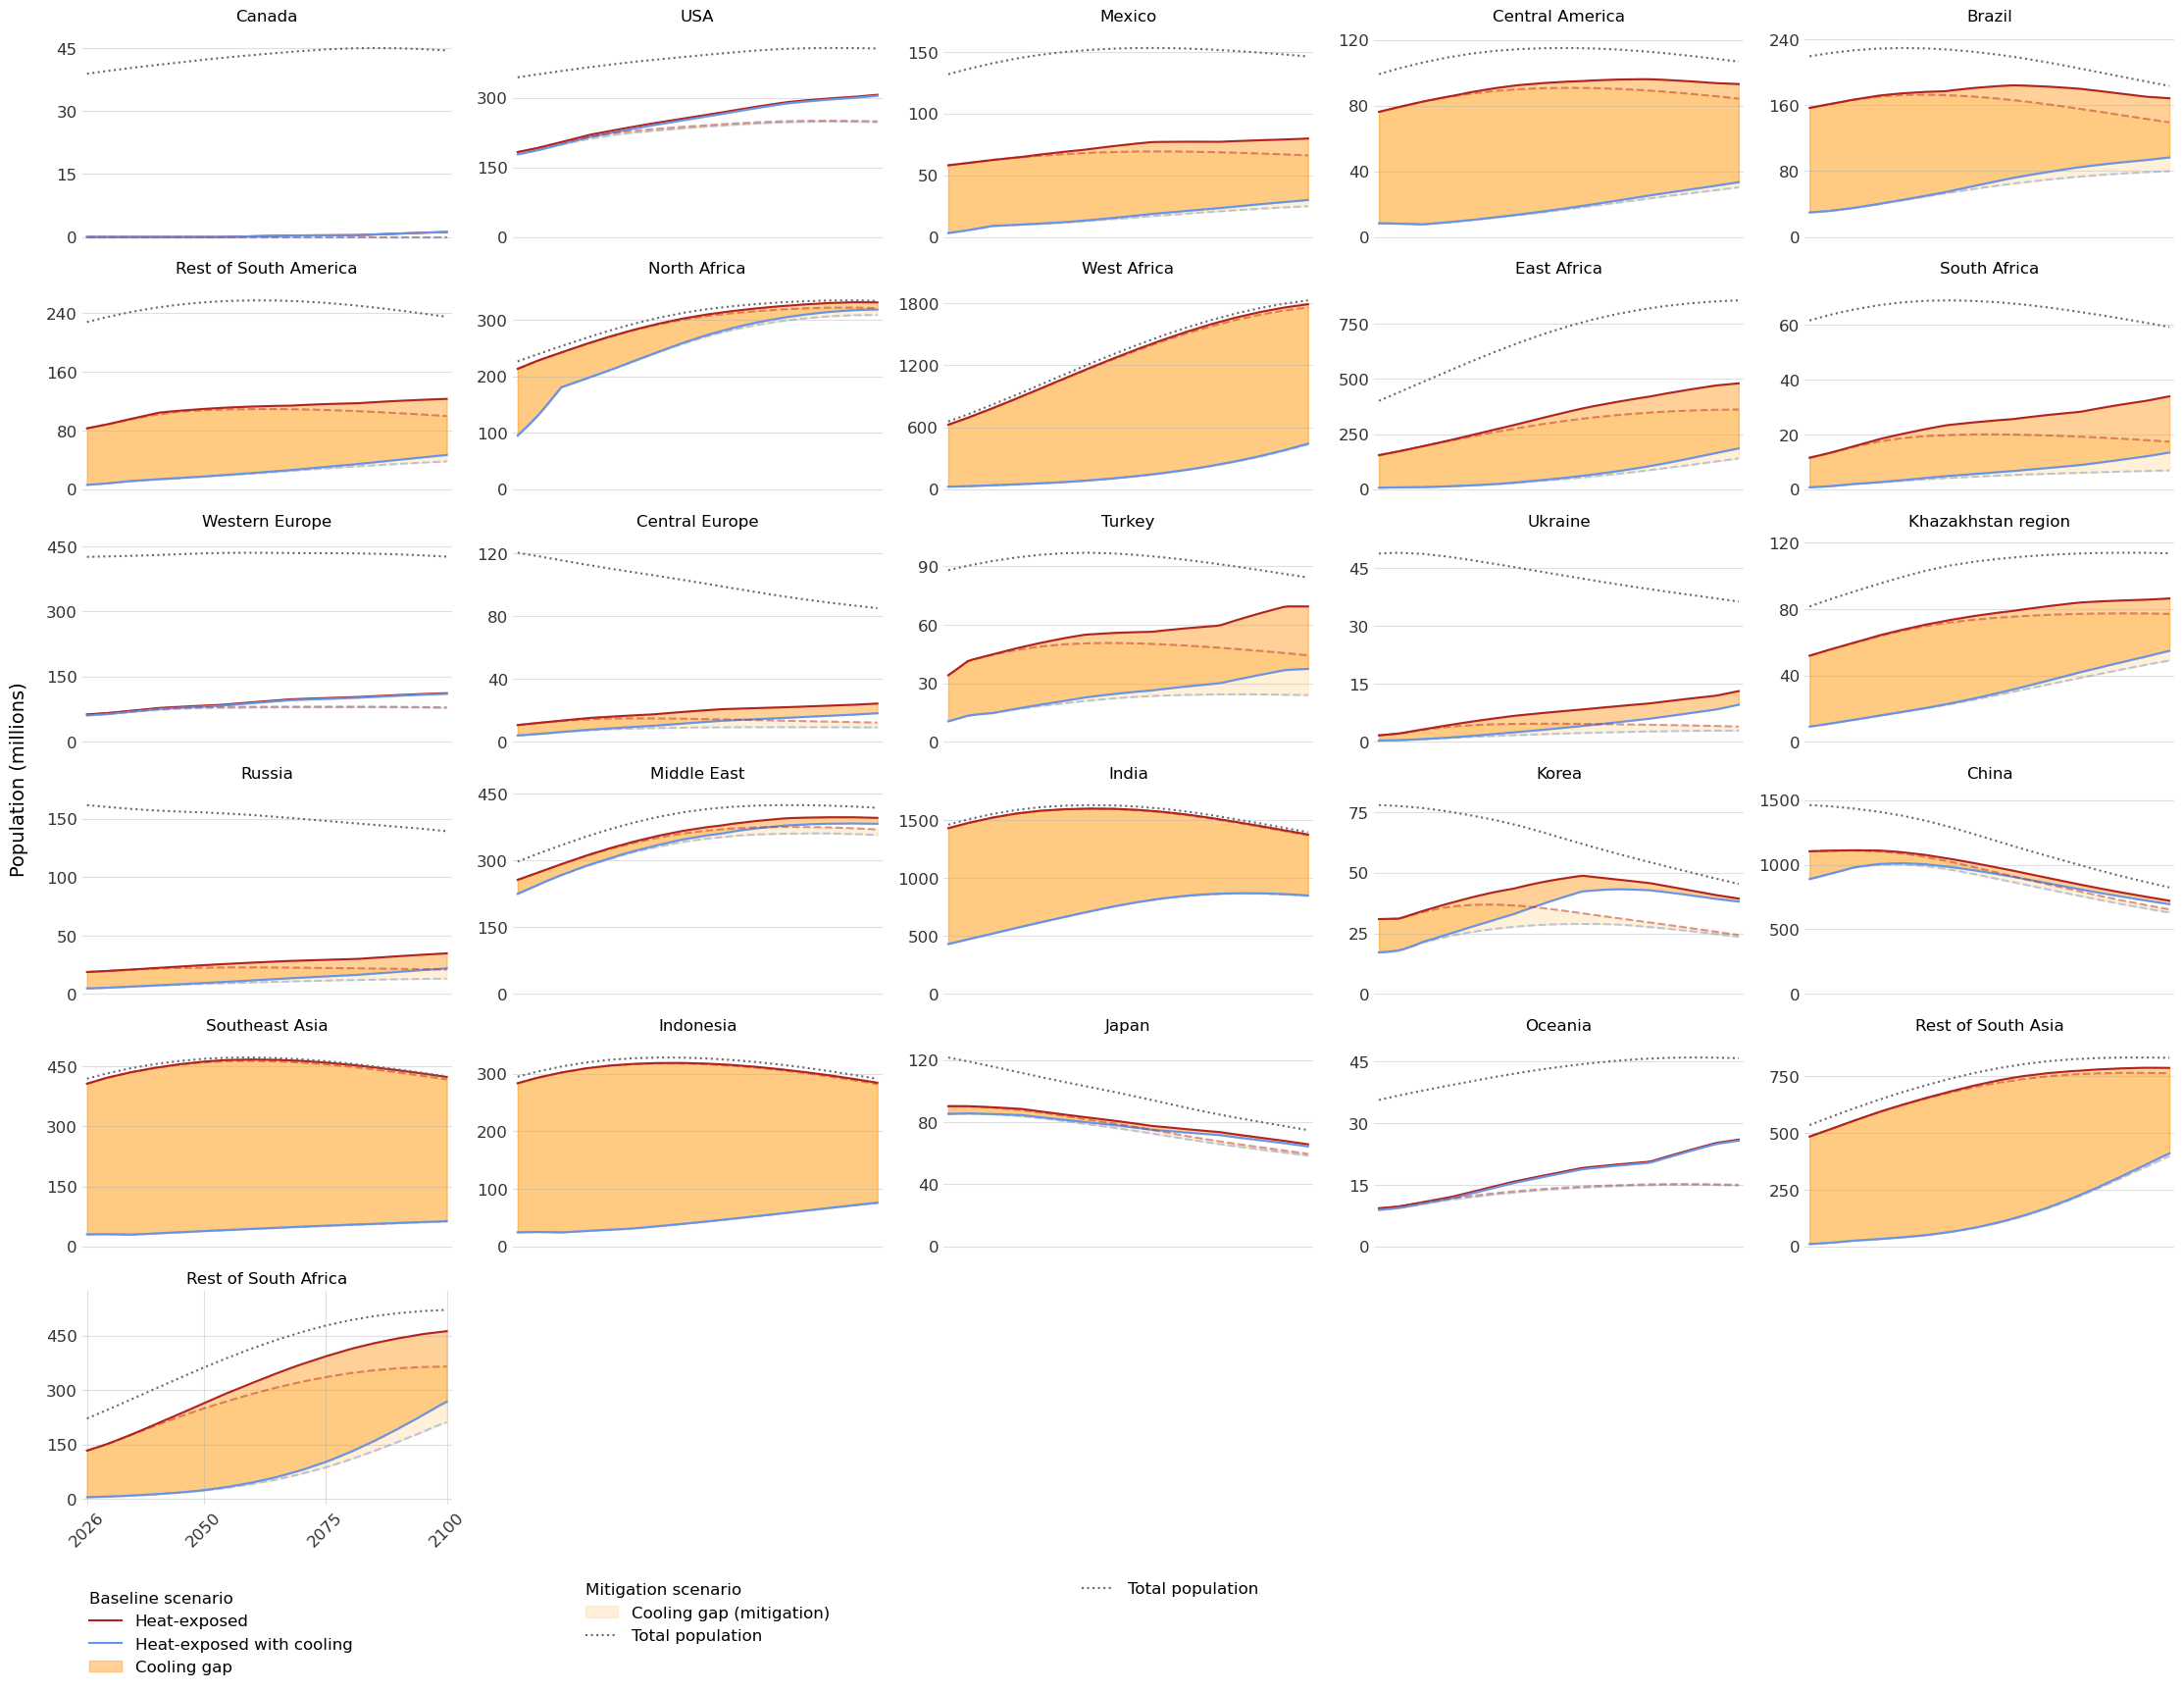

In [71]:
def regional_cooling_gap_plot_all_regions(ax, years, scens, exposed_pop, exposed_with_cooling, total_pop, region, show_xticks):

    ax.plot(years, exposed_pop[scens[0]], color='firebrick', label='Heat-exposed')
    ax.plot(years, exposed_with_cooling[scens[0]],
            color='cornflowerblue', label='Heat-exposed with cooling')
    ax.fill_between(years, exposed_pop[scens[0]], exposed_with_cooling[scens[0]],
                    interpolate=True, color='darkorange', alpha=0.4, label='Cooling gap')

    ax.plot(years, exposed_pop[scens[1]], color='firebrick', linestyle='--', alpha=0.45)
    ax.plot(years, exposed_with_cooling[scens[1]],
            color='cornflowerblue', linestyle='--', alpha=0.45)
    ax.fill_between(years, exposed_pop[scens[1]], exposed_with_cooling[scens[1]],
                    interpolate=False, color='orange', alpha=0.15, label='Cooling gap (mitigation)')

    ax.plot(years, total_pop, color='dimgrey', linestyle='dotted', label='Total population')

    xticks = [2026, 2050, 2075, 2100]
    if show_xticks:
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, color=GREY20, fontsize=12)
        ax.tick_params(axis='x', labelrotation=45)
    else:
        ax.set_xticks([])

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%0.0f'))
    for label in ax.get_yticklabels():
        label.set_color(GREY20)
        label.set_fontsize(12)
    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_tick_params(which="both", length=0)
    ax.xaxis.set_tick_params(which="both", length=0)
    ax.set_xlim(2025, 2101)
    ax.set_ylim(-3e-2 * region_max, 1.1 * region_max)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(which="major", lw=0.8, alpha=0.4)
    ax.set_title(region, color='black', fontsize=12)


ALL_REGIONS = {
    0: 'Canada', 1: 'USA', 2: 'Mexico', 3: 'Central America', 4: 'Brazil',
    5: 'Rest of South America', 6: 'North Africa', 7: 'West Africa', 8: 'East Africa',
    9: 'South Africa', 10: 'Western Europe', 11: 'Central Europe', 12: 'Turkey',
    13: 'Ukraine', 14: 'Khazakhstan region', 15: 'Russia', 16: 'Middle East',
    17: 'India', 18: 'Korea', 19: 'China', 20: 'Southeast Asia', 21: 'Indonesia',
    22: 'Japan', 23: 'Oceania', 24: 'Rest of South Asia', 25: 'Rest of South Africa',
}

regions_list = list(ALL_REGIONS.keys())
region_names = list(ALL_REGIONS.values())
n_regions = len(regions_list)
cols = 5
rows = (n_regions + cols - 1) // cols

scenarios = ['SSP2_MM', 'SSP2_20D_MM']

fig, axes = plt.subplots(rows, cols, figsize=(22, 16))
axes = axes.flatten()

for i, region in enumerate(regions_list):
    ax = axes[i]
    years = np.arange(2026, 2101)

    total_pop = all_data[scenarios[0]]['pop'].sel(
        year=years, region=region, dim2=0) / 1e6

    exposed_pop = {}
    exposed_with_cooling = {}

    for scen in scenarios:
        filtered_data = all_data[scen]

        exposed_pop[scen] = filtered_data['heat_exposed_pop'].sel(
            year=years, region=region, dim2=0) / 1e6

        exposed_with_cooling[scen] = 0
        for quintile in range(3, 12):
            heat_exposed_per_quintile = filtered_data['heat_exposed_pop'].sel(
                year=years, region=region, dim2=quintile)
            appliance_ability_per_quintile = filtered_data['appliance_diffusion'].sel(
                year=years, region=region, dim2=quintile, dim3=slice(1, 2)
            ).sum('dim3') / (
                filtered_data['appliance_saturation'].sel(
                    year=years, region=region, dim2=quintile, dim3=slice(1, 2)
                ).sum('dim3'))
            exposed_with_cooling_per_quintile = (
                heat_exposed_per_quintile -
                heat_exposed_per_quintile * (1 - appliance_ability_per_quintile)) / 1e6
            exposed_with_cooling[scen] += exposed_with_cooling_per_quintile

    region_max = max(total_pop)
    show_xticks = i >= (rows - 1) * cols

    regional_cooling_gap_plot_all_regions(ax, years, scenarios,
                              exposed_pop, exposed_with_cooling,
                              total_pop, region_names[i], show_xticks)

for j in range(n_regions, rows * cols):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
legend1 = fig.legend(handles[:3], labels[:3], loc='lower left',
                     bbox_to_anchor=(0.02, -0.08), ncol=1,
                     fontsize=12, title_fontsize=12, frameon=False,
                     title='Baseline scenario')
legend1._legend_box.align = "left"

legend2 = fig.legend(handles[3:], labels[3:], loc='lower left',
                     bbox_to_anchor=(0.25, -0.06), ncol=1,
                     fontsize=12, title_fontsize=12, frameon=False,
                     title='Mitigation scenario')
legend2._legend_box.align = "left"

legend3 = fig.legend([handles[-1]], [labels[-1]], loc='lower left',
                     bbox_to_anchor=(0.48, -0.03), ncol=1,
                     fontsize=12, frameon=False)

fig.text(-0.01, 0.5, 'Population (millions)', rotation='vertical', va='center', fontsize=14)
plt.tight_layout()
# plt.savefig(os.path.join(FIG_DIR, 'RegionalCoolingGap_AllRegions_21_05_26.png'), dpi=300, bbox_inches='tight')
plt.show()

In [72]:
# function to plot cooling gap per income quintile

ALL_REGIONS = {
    0: 'Canada', 1: 'USA', 2: 'Mexico', 3: 'Central America', 4: 'Brazil',
    5: 'Rest of South America', 6: 'North Africa', 7: 'West Africa', 8: 'East Africa',
    9: 'South Africa', 10: 'Western Europe', 11: 'Central Europe', 12: 'Turkey',
    13: 'Ukraine', 14: 'Khazakhstan region', 15: 'Russia', 16: 'Middle East',
    17: 'India', 18: 'Korea', 19: 'China', 20: 'Southeast Asia', 21: 'Indonesia',
    22: 'Japan', 23: 'Oceania', 24: 'Rest of South Asia', 25: 'Rest of South Africa',
}

def plot_income_quintiles(variable_data_dict, labels, colors, linestyles, title,
                          region_names=None):
    
    region_lookup = {v: k for k, v in ALL_REGIONS.items()}
    if region_names is None:
        region_names = list(ALL_REGIONS.values())
    regions_list = [region_lookup[name] for name in region_names]

    first_scen = list(variable_data_dict.keys())[0]
    all_regions = variable_data_dict[first_scen][0]['region']
    regions_to_plot = [r for r in regions_list if r in all_regions]
    n_regions = len(regions_to_plot)
    
    cols = 6 if n_regions > 6 else 3
    rows = math.ceil(n_regions / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.8, rows * 3), sharex=True)
    axes = np.array(axes).reshape(rows, cols)
    years = variable_data_dict[first_scen][0]['year'].where(variable_data_dict[first_scen][0]['year'] >= 2026)
    
    for i, region in enumerate(regions_to_plot):
        row = i // cols
        col = i % cols
        ax = axes[row, col]
        
        plot_idx = 0
        for scen in variable_data_dict:
            for dim_data in variable_data_dict[scen]:
                if isinstance(region, (int, np.integer)):
                    data = dim_data.sel(region=region)
                else:
                    data = dim_data.sel(region=region.item())
                
                ax.plot(years, data, color=colors[plot_idx], linestyle=linestyles[plot_idx],
                        label=labels[plot_idx] if i == 0 else '')
                plot_idx += 1
        
        ax.set_axisbelow(True)
        major_yticks = np.arange(0, 1.1, 0.25)
        ax.set_yticks(major_yticks)
        ax.grid(True, axis='both', which='major', linestyle='-', alpha=0.4, linewidth=0.8)
        ax.set_ylim(-0.05, 1.01)
        ax.set_xlim(2025, 2101)
        major_xticks = [2026,2050,2075,2100]
        ax.set_xticks(major_xticks)
        ax.set_xticklabels(major_xticks, color=GREY20, fontsize=12.5)
        ax.yaxis.set_tick_params(which="both", length=0)
        ax.xaxis.set_tick_params(which="both", length=0, rotation=45)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        if col > 0:
            ax.set_yticklabels([])
        if col == 0:
            ax.set_yticklabels([f'{int(y*100)}%' for y in major_yticks], color=GREY20, fontsize=12)

        region_title = region_names[i]
        ax.set_title(region_title, color='black', fontsize=15, pad=7)

    for i in range(n_regions, rows * cols):
        row = i // cols
        col = i % cols
        axes[row, col].set_visible(False)
        
    legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.1),
               ncol=2, frameon=False, fontsize=13)
    
    fig.text(-0.03,0.55,'Share of quintile population in the cooling gap\n',rotation='vertical', va='center', color=GREY20, fontsize=13)
    plt.setp(legend.get_label(), color=GREY20)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    # plt.savefig(FIG_DIR + f'{title}_21_05_26.svg', bbox_inches='tight', dpi=300)
    plt.show()

In [73]:
# ## CHANGE INPUTS HERE FOR INCOME QUINTILE PLOTS ##
scens_ssp2_baseline_and_mitig_mm = ['SSP2_MM', 'SSP2_20D_MM']
# urban_data = {scen: [all_data[scen]['cooling_gap_pop_share'].sel(dim2=d) for d in [3, 7]] for scen in scens_ssp2_baseline_and_mitig_mm}
# rural_data = {scen: [all_data[scen]['cooling_gap_pop_share'].sel(dim2=d) for d in [8, 12]] for scen in scens_ssp2_baseline_and_mitig_mm}

# plot_income_quintiles(
#     variable_data_dict=urban_data,
#     labels=['Poorest quintile (Baseline scenario)', 'Richest quintile',
#             'Poorest quintile (Mitigation scenario)', 'Richest quintile'],
#              colors=['tan', 'mediumaquamarine', 'tan', 'mediumaquamarine'],
#              linestyles=['solid', 'solid', 'dashed', 'dashed'],
#     title='income_quintiles_cooling_gap_urban',
#     region_names=['Brazil', 'West Africa', 'South Africa', 'Russia', 'India', 'China'])

# plot_income_quintiles(
#     variable_data_dict=rural_data,
#     labels=['Poorest quintile (Baseline scenario)', 'Richest quintile',
#             'Poorest quintile (Mitigation scenario)', 'Richest quintile'],
#              colors=['tan', 'mediumaquamarine', 'tan', 'mediumaquamarine'],
#              linestyles=['solid', 'solid', 'dashed', 'dashed'],
#     title='income_quintiles_cooling_gap_rural',
#     region_names=['Brazil', 'West Africa', 'South Africa', 'Russia', 'India', 'China'])


In [74]:
# # PLOT INCOME QUINTILES FOR ALL REGIONS FOR SI
# plot_income_quintiles(
#     variable_data_dict=urban_data,
#     labels=['Poorest quintile (Baseline scenario)', 'Richest quintile',
#             'Poorest quintile (Mitigation scenario)', 'Richest quintile'],
#     colors=['tan', 'mediumaquamarine', 'tan', 'mediumaquamarine'],
#     linestyles=['solid', 'solid', 'dashed', 'dashed'],
#     title='income_quintiles_cooling_gap_urban_all',
# )
# plot_income_quintiles(
#     variable_data_dict=rural_data,
#     labels=['Poorest quintile (Baseline scenario)', 'Richest quintile',
#             'Poorest quintile (Mitigation scenario)', 'Richest quintile'],
#     colors=['tan', 'mediumaquamarine', 'tan', 'mediumaquamarine'],
#     linestyles=['solid', 'solid', 'dashed', 'dashed'],
#     title='income_quintiles_cooling_gap_rural_all',
# )

In [106]:
# function to plot energy demand for cooling across regions, scenarios and AC techs
ALL_REGIONS_WITH_WORLD = {
    0: 'Canada', 1: 'USA', 2: 'Mexico', 3: 'Central America', 4: 'Brazil',
    5: 'Rest of South America', 6: 'North Africa', 7: 'West Africa', 8: 'East Africa',
    9: 'South Africa', 10: 'Western Europe', 11: 'Central Europe', 12: 'Turkey',
    13: 'Ukraine', 14: 'Khazakhstan region', 15: 'Russia', 16: 'Middle East',
    17: 'India', 18: 'Korea', 19: 'China', 20: 'Southeast Asia', 21: 'Indonesia',
    22: 'Japan', 23: 'Oceania', 24: 'Rest of South Asia', 25: 'Rest of South Africa',
    26: 'World'
}

def plot_energy_use_by_tech_and_scenario(all_data, title, region_names=None):
    
    region_lookup = {v: k for k, v in ALL_REGIONS_WITH_WORLD.items()}
    if region_names is None:
        region_names = list(ALL_REGIONS.values())
    regions = [region_lookup[name] for name in region_names]
    region_labels = [name + '\n' for name in region_names]

    target_years = [2026, 2050, 2100]
    all_scenarios = {
        'SSP2_MM': 'Baseline',
        'SSP2_NO_GAP_ELEC_MM': 'Adaptation',
        'SSP2_20D_MM': 'Mitigation',
        'SSP2_NO_GAP_ELEC_20D_MM': 'Adaptation-Mitigation',
        'SSP2_NO_GAP_ELEC_SUST_20D_MM': 'Integrated Adaptation-Mitigation',
    }
    scenario_keys = list(all_scenarios.keys())
    scenario_labels = list(all_scenarios.values())
    
    n_regions = len(regions)
    n_scenarios = len(all_scenarios)
    fig, axes = plt.subplots(n_regions, 1, figsize=(12, 2*n_regions))
 
    colors = {'SSP2_MM': '#ffca3a', 'SSP2_20D_MM': '#1982c4',
              'SSP2_NO_GAP_ELEC_MM': '#F8494F', 'SSP2_NO_GAP_ELEC_20D_MM': '#6a4c93',
              'SSP2_NO_GAP_ELEC_SUST_20D_MM': '#8ac926',
              }
    hatches = ["////", 'xxxx']
    
    bar_width = 0.8
    scenario_width = bar_width / n_scenarios
    
    for row, (region, region_label) in enumerate(zip(regions, region_labels)):
        ax = axes[row]
        baseline_values = {}
        
        for year_idx, year in enumerate(target_years):
            scenarios_for_year = ['SSP2_MM'] if year == 2026 else scenario_keys
            
            for j, scenario in enumerate(scenarios_for_year):
                value_air_conditioner = all_data[scenario]['energy_use'].sel(
                    year=year, region=region, dim2=0, dim3=2).item()/ 1e9
                value_air_cooler = all_data[scenario]['energy_use'].sel(
                    year=year, region=region, dim2=0, dim3=1).item()/ 1e9
                total_value = value_air_conditioner + value_air_cooler
                
                if scenario == 'SSP2_MM':
                    baseline_values[year] = total_value

                if year == 2026:
                    x_pos = 1
                elif year == 2050:
                    x_pos = (j/4 + year_idx * n_scenarios) - 3.5
                else:
                    x_pos = (j/4 + year_idx * n_scenarios) - 7
                
                scenario_idx = scenario_keys.index(scenario)

                bars1 = ax.bar(x_pos, value_air_conditioner, scenario_width,
                             color=colors[scenario], alpha=1,
                             hatch=hatches[0],
                             edgecolor='black',
                             bottom=value_air_cooler,
                             label=scenario_labels[scenario_idx] if year_idx == 1 and scenario == scenario_labels[scenario_idx] else '',
                             zorder=2)
                bars2 = ax.bar(x_pos, value_air_cooler, scenario_width,
                             color=colors[scenario], alpha=1, 
                             hatch=hatches[1],
                             edgecolor='black',
                             label=scenario_labels[scenario_idx] if year_idx == 1 and scenario == scenario_labels[scenario_idx] else '',
                             zorder=2)
                
                if scenario != 'SSP2_MM' and year in baseline_values and baseline_values[year] != 0:
                    percent_change = (total_value - baseline_values[year]) / baseline_values[year] * 100
                    sign = '+' if percent_change >= 0 else ''
                    ax.text(x_pos, total_value, f'{sign}{percent_change:.0f}%', ha='center', va='bottom', fontsize=11, color=GREY20)

                if row == n_regions - 1:
                    ax.plot(0, -0.03,
                            color=colors[scenario],
                            markersize=12,
                            transform=ax.get_xaxis_transform(),
                            clip_on=False)

        ax.hlines(y=baseline_values[2050], xmin=1.575, xmax=2.58, color=GREY20, linewidth=0.8, linestyle='--', zorder=0, alpha=0.5)
        ax.hlines(y=baseline_values[2100], xmin=3.05, xmax=4.08, color=GREY20, linewidth=0.8, linestyle='--', zorder=0, alpha=0.5)
        ax.text(-0.04, 1.05, region_label.strip(), transform=ax.transAxes, ha='left', va='center', fontsize=15, color='black')
        ax.yaxis.set_major_locator(MaxNLocator(3))
        for label in ax.get_yticklabels():
            label.set_color(GREY20)
            label.set_fontsize(12)
        ax.set_xticks([])
        ax.grid(True, axis='y', linestyle='-', alpha=0.25, linewidth=0.8, zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(True)
        ax.spines['bottom'].set_color(GREY20)
        ax.yaxis.set_tick_params(which="both", length=0)
        ax.xaxis.set_tick_params(which="both", length=0)

    legend_tech_elements = [
        Patch(facecolor='white', hatch=hatches[0], label='Air conditioner', linewidth=0.5),
        Patch(facecolor='white', hatch=hatches[1], label='Evaporative cooler', linewidth=1)
    ]
    legend_tech = fig.legend(handles=legend_tech_elements,
                        loc='lower right', frameon=False, fontsize=13,
                        bbox_to_anchor=(0.88, -0.062), ncol=1,
                        title='Cooling technology', title_fontsize=13,
                        handlelength=1, handleheight=1)
    legend_tech._legend_box.align = "left"


    scenario_legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor=colors[s],
               markersize=13, label=scenario_labels[scenario_keys.index(s)])
        for s in scenario_keys
    ]
    scenario_legend = fig.legend(
        handles=scenario_legend_elements,
        loc='lower left', frameon=False, fontsize=13,
        bbox_to_anchor=(0.1, -0.08), ncol=2,
        title='Scenario', title_fontsize=13)
    scenario_legend._legend_box.align = "left"

    year_bands = {
        '2026': (0.7, 1.2),
        '2050': (1.3, 2.7),
        '2100': (2.8, 4.15)}
    band_color = '#e2e2e2'
    for year_label, (x_start, x_end) in year_bands.items():
        for ax in axes:
            ax.axvspan(x_start, x_end, color=band_color, alpha=0.5, zorder=0)
        axes[0].text((x_start + x_end) / 2, 1.08, year_label,
                    ha='center', va='bottom', fontsize=15, color=GREY20,
                    transform=axes[0].get_xaxis_transform(), fontweight='bold')
        
    fig.text(-0.03, 0.5, "Energy Use (EJ)", fontsize=15, color='black', rotation='vertical')
    fig.subplots_adjust(left=0.15, hspace=0.7)
    for ax in axes:
        ax.set_xlim(axes[0].get_xlim())

    plt.tight_layout()
    plt.savefig(FIG_DIR + f'{title}_11_06_26.svg', bbox_inches='tight', dpi=300)
    plt.show()

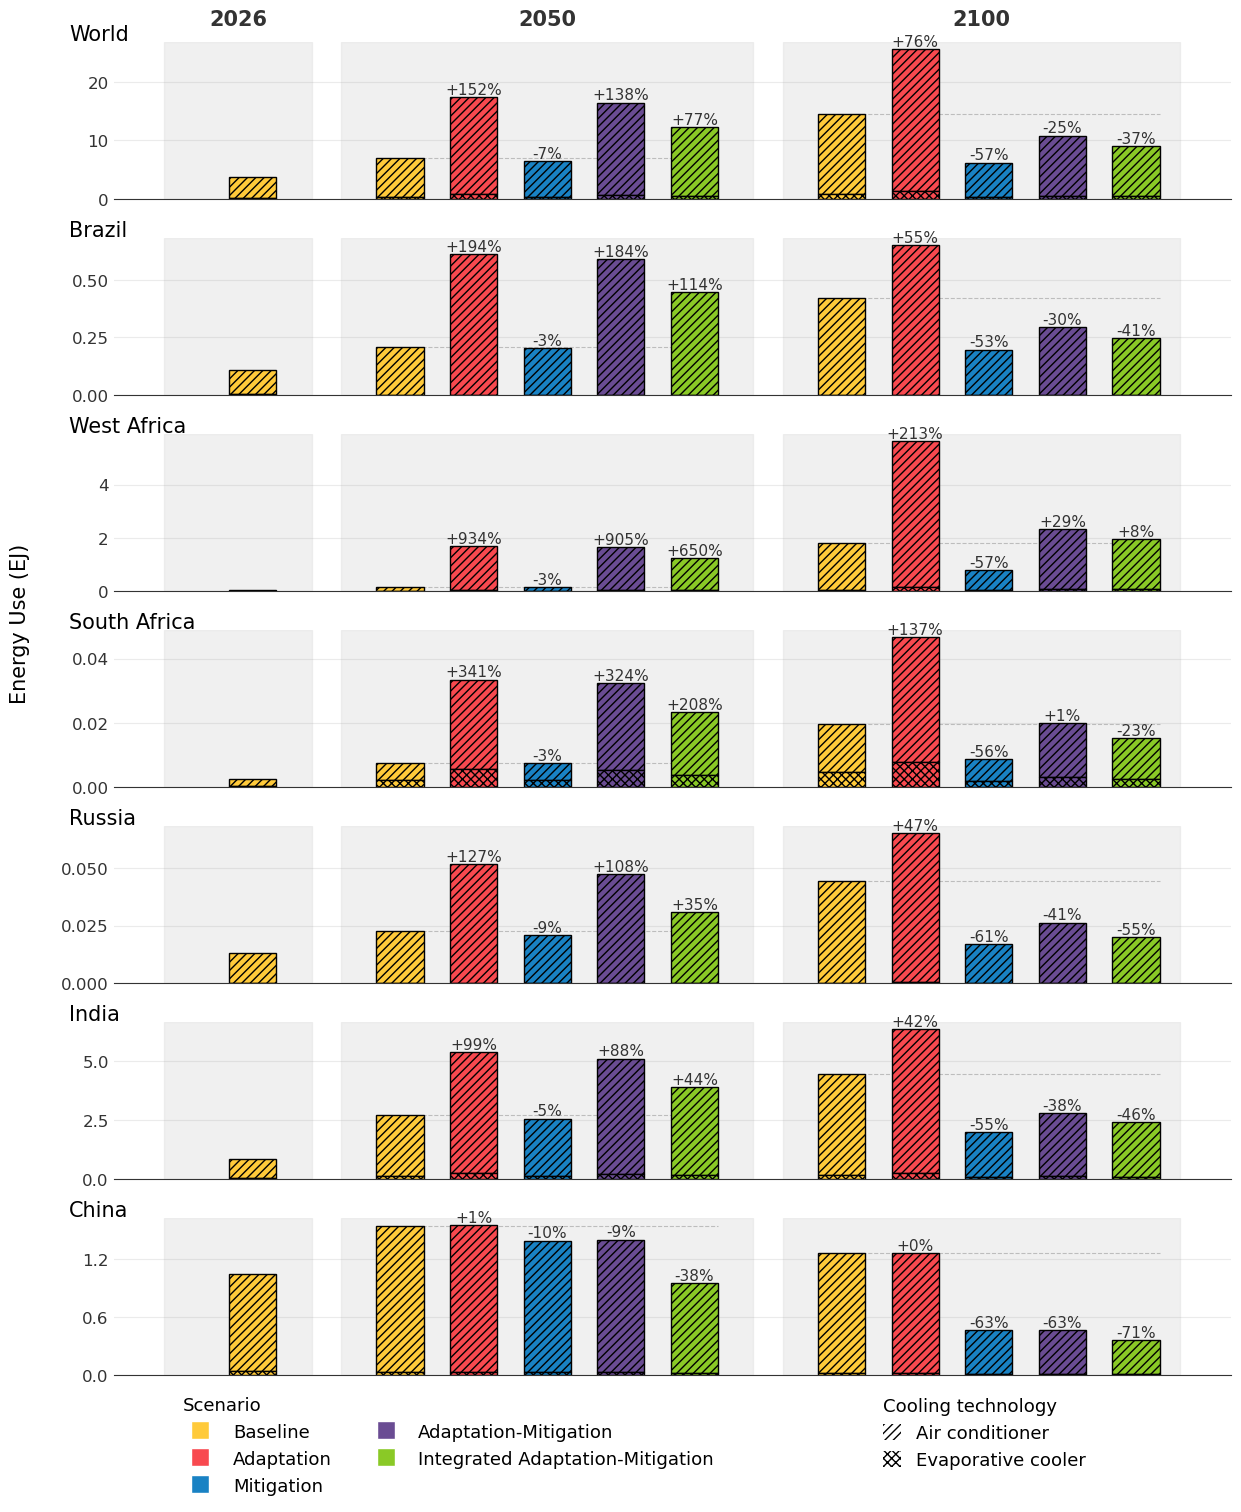

In [107]:
# plot energy demand figure for the 6 regions
plot_energy_use_by_tech_and_scenario(
    all_data,
    region_names=['World', 'Brazil', 'West Africa', 'South Africa', 'Russia', 'India', 'China'],
    title='Energy_demand_SSP2_MM'
)

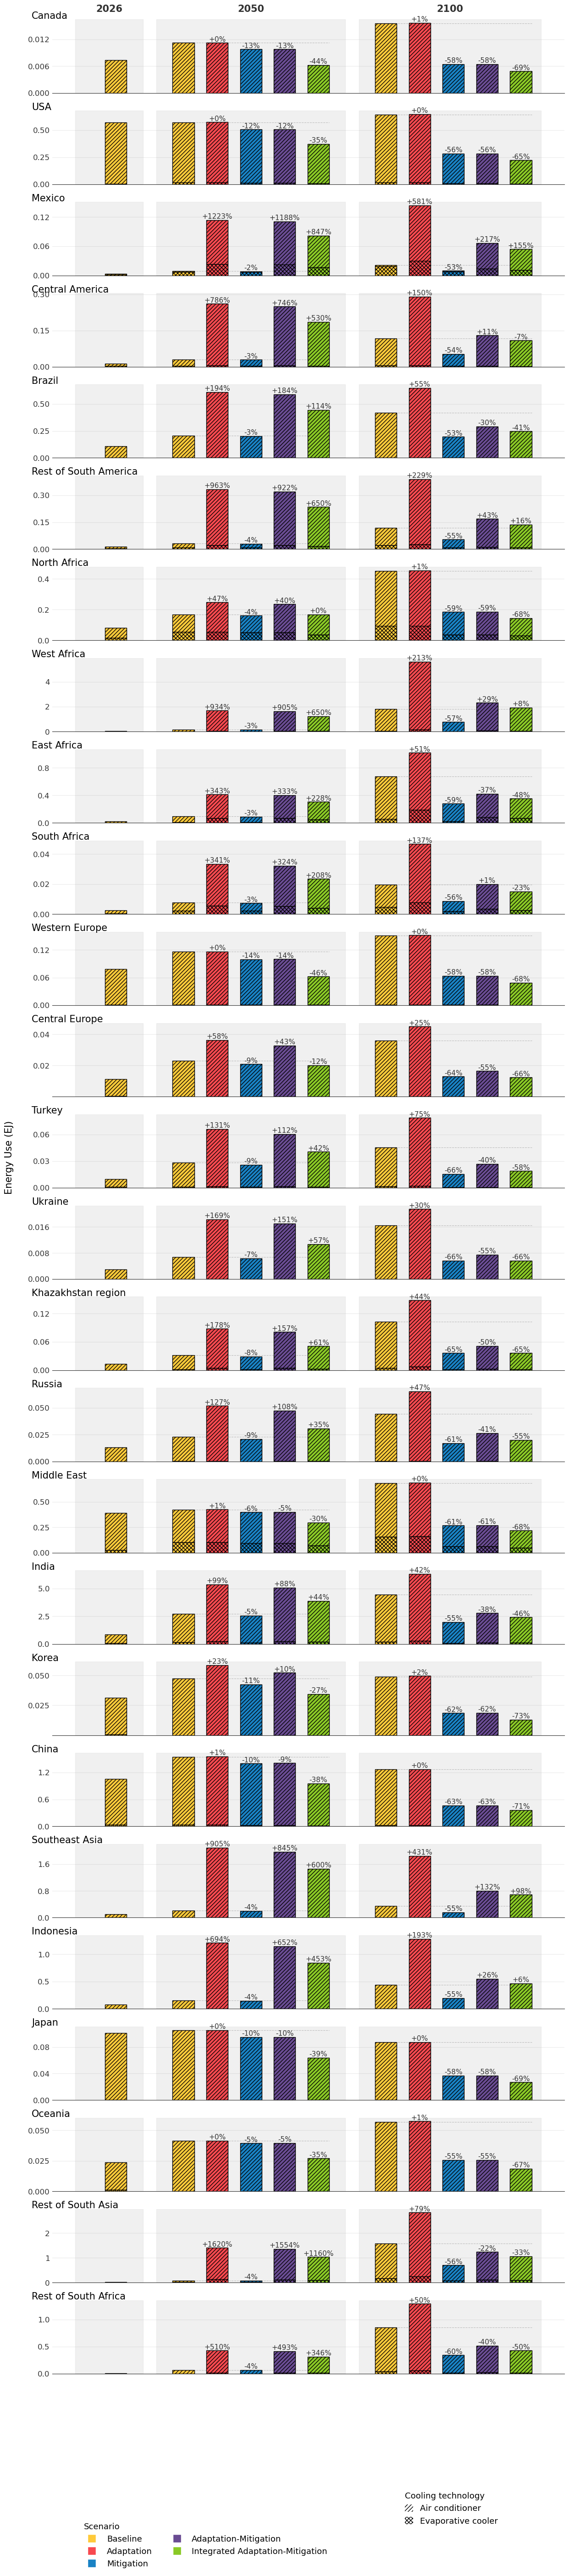

In [77]:
# plot energy demand figure with all regions for SI
plot_energy_use_by_tech_and_scenario(all_data, title='Energy_demand_ssp2_all_regions_MM')

In [78]:
# # plot energy demand across UHI assumptions
# def plot_energy_use_uhi_assumptions(all_data, title):

#     target_years = [2050, 2100]
#     scenarios = {
#         'SSP2_MM': 'Method 1 - Absolute changes in CDD/HDD',
#         'SSP2_RELATIVE_UHI_MM': 'Method 2 - Relative changes in CDD/HDD',
#         'SSP2_NO_UHI_MM': 'No UHI',
#     }
#     scenario_keys = list(scenarios.keys())
#     scenario_labels = list(scenarios.values())

#     colors = {
#         'SSP2_MM':           '#ffca3a',
#         'SSP2_RELATIVE_UHI_MM':   '#F8494F',
#         'SSP2_NO_UHI_MM':'#6a9fd8',
#     }
#     n_scenarios = len(scenario_keys)
#     bar_width = 0.25
#     group_gap = 0.3

#     fig, ax = plt.subplots(figsize=(9, 5))

#     baseline_values = {}
#     def group_center(year_idx):
#         return year_idx * (n_scenarios * bar_width + group_gap)

#     def bar_x(year_idx, scenario_idx):
#         center = group_center(year_idx)
#         offset = (scenario_idx - (n_scenarios - 1) / 2) * bar_width
#         return center + offset

#     for year_idx, year in enumerate(target_years):
#         for j, scenario in enumerate(scenario_keys):
#             value = all_data[scenario]['energy_use'].sel(
#                 year=year, region=26, dim2=0, dim3=[2,3]).sum().item() / 1e9

#             if scenario == 'SSP2_MM':
#                 baseline_values[year] = value

#             x_pos = bar_x(year_idx, j)

#             ax.bar(x_pos, value, bar_width,
#                     color=colors[scenario], zorder=2)

#             if scenario != 'SSP2_MM' and baseline_values.get(year):
#                 pct = (value - baseline_values[year]) / baseline_values[year] * 100
#                 sign = '+' if pct >= 0 else ''
#                 ax.text(x_pos, value, f'{sign}{pct:.0f}%',
#                          ha='center', va='bottom', fontsize=10, color=GREY20)

#     ax.set_xticks([group_center(i) for i in range(len(target_years))])
#     ax.set_xticklabels([str(y) for y in target_years], fontsize=13, color=GREY20)

#     ax.yaxis.set_major_locator(MaxNLocator(4))
#     for label in ax.get_yticklabels():
#         label.set_color(GREY20)
#         label.set_fontsize(12)
#     ax.set_ylabel("Energy Use (EJ)", fontsize=13, color=GREY20)

#     ax.grid(True, axis='y', linestyle='-', alpha=0.25, linewidth=0.8, zorder=0)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.spines['left'].set_visible(False)
#     ax.spines['bottom'].set_color(GREY20)
#     ax.yaxis.set_tick_params(which="both", length=0)

#     scenario_legend = [
#         Line2D([0], [0], marker='s', color='w', markerfacecolor=colors[s],
#                markersize=12, label=scenario_labels[i])
#         for i, s in enumerate(scenario_keys)
#     ]
#     ax.legend(handles=scenario_legend,
#                frameon=False, fontsize=12, loc='upper left', title_fontsize=12)

#     plt.tight_layout()
#     # plt.savefig(FIG_DIR + f'{title}_21_05_26.png', bbox_inches='tight', dpi=300)
#     plt.show()

# plot_energy_use_uhi_assumptions(all_data, title='Energy_demand_world_SSP2_no_UHI_MM')

In [16]:
# function to plot emissions across scenarios
def plot_emissions(variable_data, labels, colors, linestyles, title, y_label):

    fig, ax = plt.subplots(figsize=(5,4))  
    filtered_data = [data.where(data['year'] >= 2026, drop=True) for data in variable_data]
    years = filtered_data[0]['year']    
    current_max = 0

    current_max = 0
    for data in filtered_data:
        data_max = data.max().item() if hasattr(data.max(), 'item') else data.max()
        current_max = max(current_max, data_max)

    for j, data in enumerate(filtered_data):
        plt.plot(years, data, color=colors[j], linestyle=linestyles[j], label=labels[j])

    ax.set_axisbelow(True)
    yticks = [0,10,20,30,40]
    ax.set_yticks(yticks)
    # ax.set_yticklabels(yticks, fontsize=10, color=GREY20)
    plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    xticks=[2026,2050,2075,2100]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=11, color=GREY20)
    ax.grid(True, linestyle='-', axis='both', alpha=0.7)
    ax.set_ylim(-4, 1.05*current_max)
    ax.set_xlim(2025,2100.5)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_tick_params(which="both", length=0)
    ax.xaxis.set_tick_params(which="both", length=0)
    ax.axhline(y=0, color=GREY20, linestyle='-', alpha=0.5, linewidth=1)
    
    fig.text(0.01, 0.5, y_label, va='center', rotation='vertical', fontsize=12, color=GREY20)
    legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.2),
               ncol=2, frameon=False, fontsize=10, title='Scenario', title_fontsize=10)
    legend._legend_box.align = "left"
    plt.tight_layout(rect=[0.043, 0.08, 0.95, 0.95])
    plt.title('')
    plt.savefig(FIG_DIR + f'{title}_11_06_25.pdf', bbox_inches='tight')
    plt.show()

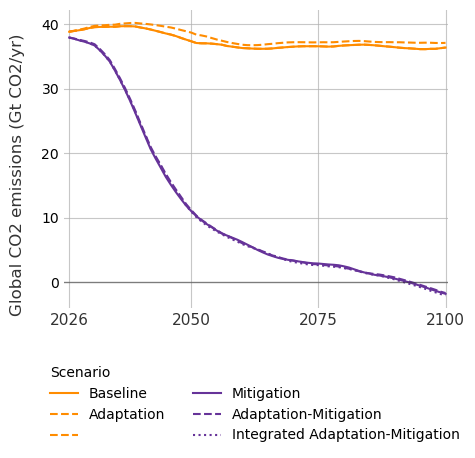

In [17]:
# plot global emissions across scenarios
blank_data = all_data['SSP2_MM']['emis'].sel(region=27, dim2=20, dim3=6) *3.667
emis_ssp2_data = all_data['SSP2_MM']['emis'].sel(region=27, dim2=20, dim3=6)*3.667
emis_2dC_data = all_data['SSP2_20D_MM']['emis'].sel(region=27, dim2=20, dim3=6) *3.667
emis_high_adaptation_data = all_data['SSP2_NO_GAP_ELEC_MM']['emis'].sel(region=27, dim2=20, dim3=6) *3.667
emis_high_adaptation_2dC_data = all_data['SSP2_NO_GAP_ELEC_20D_MM']['emis'].sel(region=27, dim2=20, dim3=6) *3.667
emis_integ_high_adaptation_2dC_data = all_data['SSP2_NO_GAP_ELEC_SUST_20D_MM']['emis'].sel(region=27, dim2=20, dim3=6) *3.667
plot_emissions(
     variable_data=[
          emis_ssp2_data,
          emis_high_adaptation_data,
          blank_data,
          emis_2dC_data,
          emis_high_adaptation_2dC_data,
          emis_integ_high_adaptation_2dC_data
     ],
     labels=[
          'Baseline',
          'Adaptation',
          '',
          'Mitigation',
          'Adaptation-Mitigation',
          'Integrated Adaptation-Mitigation'
     ],
     colors=[
            'darkorange',
            'darkorange',
            'darkorange',
            'rebeccapurple',
            'rebeccapurple',
            'rebeccapurple'
     ],
     linestyles=[
            'solid',
            'dashed',
            'dashed',
            'solid',
            'dashed',
            'dotted'
     ],
     title='emissions_ssp2',
     y_label='Global CO2 emissions (Gt CO2/yr)'
)

In [81]:
# function to plot GMT across scenarios
def plot_gmt(scenarios, colors, linestyles, title, y_label):

    fig, ax = plt.subplots(figsize=(5,4))

    variable_data = [
        all_data[s]['gmt'] if not s.startswith('__') else all_data['SSP2_MM']['gmt']
        for s in scenarios
    ]
    labels = list(scenarios.values())
    filtered_data = [data.where(data['year'] >= 2026, drop=True) for data in variable_data]
    years = filtered_data[0]['year']

    current_max = 0
    for data in filtered_data:
        data_max = data.max().item() if hasattr(data.max(), 'item') else data.max()
        current_max = max(current_max, data_max)

    for j, data in enumerate(filtered_data):
        ax.plot(years, data, color=colors[j], linestyle=linestyles[j], label=labels[j])

    ax.set_axisbelow(True)
    yticks = [0, 0.5, 1, 1.5, 2, 2.5, 3]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=10, color=GREY20)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    xticks = [2026, 2050, 2075, 2100]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=11, color=GREY20)
    ax.grid(True, linestyle='-', axis='both', alpha=0.7)
    ax.set_ylim(-0.1, 1.05 * current_max)
    ax.set_xlim(2026, 2100.5)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_tick_params(which="both", length=0)
    ax.xaxis.set_tick_params(which="both", length=0)
    ax.axhline(y=0, color=GREY20, linestyle='-', alpha=0.5, linewidth=1)

    fig.text(0.01, 0.5, y_label, va='center', rotation='vertical', fontsize=12, color=GREY20)
    legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.2),
                        ncol=2, frameon=False, fontsize=10, title='Scenario', title_fontsize=10)
    legend._legend_box.align = "left"
    plt.tight_layout(rect=[0.043, 0.08, 0.95, 0.95])
    plt.savefig(FIG_DIR + f'{title}_11_06_26.svg', bbox_inches='tight')
    plt.show()

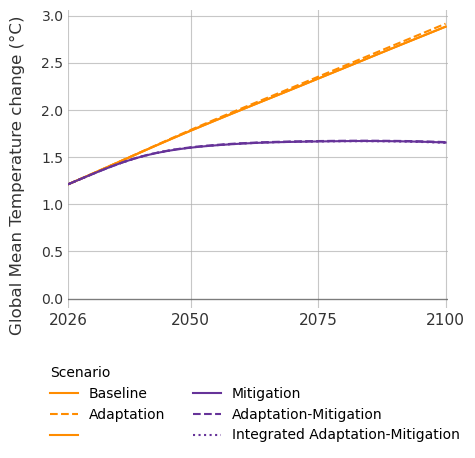

In [82]:
# plot GMT across scenarios
scenarios = {
    'SSP2_MM': 'Baseline',
    'SSP2_NO_GAP_ELEC_MM': 'Adaptation',
    '__gap__': '',
    'SSP2_20D_MM': 'Mitigation',
    'SSP2_NO_GAP_ELEC_20D_MM': 'Adaptation-Mitigation',
    'SSP2_NO_GAP_ELEC_SUST_20D_MM': 'Integrated Adaptation-Mitigation',
}
colors     = ['darkorange', 'darkorange', 'darkorange', 'rebeccapurple', 'rebeccapurple', 'rebeccapurple']
linestyles = ['solid', 'dashed', 'solid', 'solid', 'dashed', 'dotted']

plot_gmt(scenarios, colors, linestyles, title='gmt_ssp2_MM', y_label='Global Mean Temperature change (°C)')

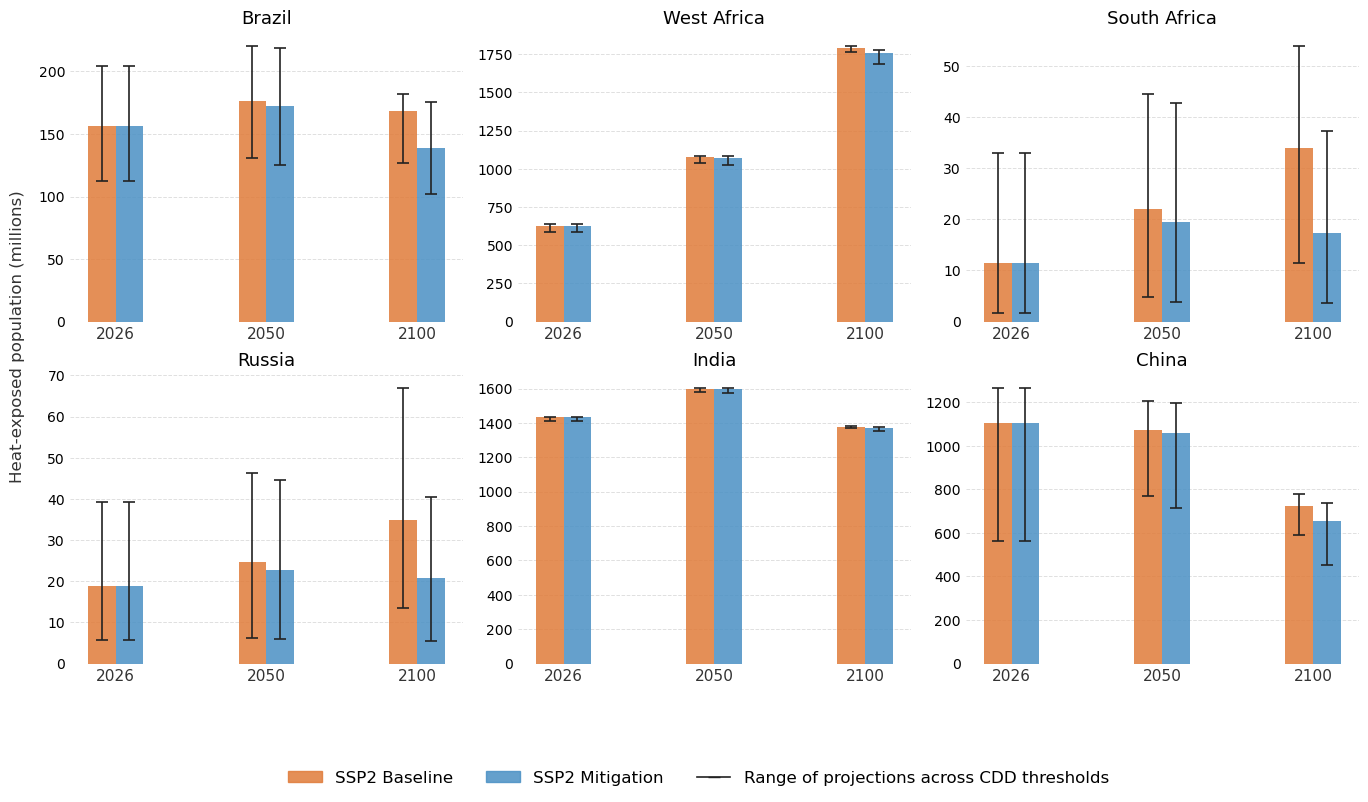

In [115]:
YEARS = [2026, 2050, 2100]
REGIONS = {
    4: 'Brazil',
    7: 'West Africa',
    9: 'South Africa',
    15: 'Russia',
    17: 'India',
    19: 'China'
}
REGIONS_TO_PLOT = ['Brazil', 'West Africa', 'South Africa', 'Russia', 'India', 'China']
region_lookup = {v: k for k, v in REGIONS.items()}

scenario_colors = {
    'SSP2_MM':      '#E07B39',  # warm orange  → baseline
    'SSP2_20D_MM':  '#4A90C4',
}
scenario_labels = {
    'SSP2_MM':     'SSP2 Baseline',
    'SSP2_20D_MM': 'SSP2 Mitigation',
}

n_scens   = len(scens_ssp2_baseline_and_mitig_mm)
n_years   = len(YEARS)
bar_width = 0.35
group_gap = 1.2   # space between year-groups
cap_size  = 4     # whisker cap width in points


def plot_heat_exposure_bars(region_names=REGIONS_TO_PLOT):
    cols = 3
    rows = math.ceil(len(region_names) / cols)
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 4.5, rows * 3.8),
                             sharey=False)
    axes = np.array(axes).reshape(rows, cols)

    bar_data = {}   # bar_data[scen][year][region]  → scalar
    whisker_data = {} 

    for scen in scens_ssp2_baseline_and_mitig_mm:
        median_da  = all_data[scen]['heat_exposed_pop'].sel(dim2=0) /1e6
        thresh_da  = all_data[scen]['heat_exposed_pop_per_threshold'].sel(dim2=0) /1e6

        bar_data[scen] = {}
        whisker_data[scen] = {}
        for yr in YEARS:
            bar_data[scen][yr] = {}
            whisker_data[scen][yr] = {}
            for name in region_names:
                reg = region_lookup[name]
                bar_data[scen][yr][name] = float(
                    median_da.sel(year=yr, region=reg))
                t_vals = thresh_da.sel(year=yr, region=reg).values
                whisker_data[scen][yr][name] = (float(t_vals.min()),
                                            float(t_vals.max()))

    # plot
    for idx, name in enumerate(region_names):
        ax = axes[idx // cols, idx % cols]

        group_centers = np.arange(n_years) * (n_scens * bar_width + group_gap)

        for s_i, scen in enumerate(scens_ssp2_baseline_and_mitig_mm):
            color  = scenario_colors[scen]
            x_bars = group_centers + s_i * bar_width

            heights = [bar_data[scen][yr][name] for yr in YEARS]
            lo      = [bar_data[scen][yr][name] - whisker_data[scen][yr][name][0]
                       for yr in YEARS]
            hi      = [whisker_data[scen][yr][name][1] - bar_data[scen][yr][name]
                       for yr in YEARS]

            ax.bar(x_bars, heights,
                   width=bar_width,
                   color=color, alpha=0.85,
                   zorder=2)

            ax.errorbar(x_bars, heights,
                        yerr=[lo, hi],
                        fmt='none',
                        ecolor='#222222', elinewidth=1.2,
                        capsize=cap_size, capthick=1.2,
                        zorder=3)

        group_mid = group_centers + (n_scens - 1) * bar_width / 2
        ax.set_xticks(group_mid)
        ax.set_xticklabels(YEARS, fontsize=11, color=GREY20)

        ax.set_ylim(bottom=0)
        ax.set_title(name, fontsize=13, color='black', pad=6)
        ax.set_axisbelow(True)
        ax.grid(True, axis='y', linestyle='--', alpha=0.4, linewidth=0.7)
        ax.yaxis.set_tick_params(which='both', length=0)
        ax.xaxis.set_tick_params(which='both', length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

    for i in range(len(region_names), rows * cols):
        axes[i // cols, i % cols].set_visible(False)

    legend_handles = [
        mpatches.Patch(color=scenario_colors[scen], alpha=0.85,
                       label=scenario_labels[scen])
        for scen in scens_ssp2_baseline_and_mitig_mm
    ] + [
        Line2D([0], [0], color='#222222', linewidth=1.2,
               marker='_', markersize=8, label='Range of projections across CDD thresholds')
    ]
    fig.legend(handles=legend_handles,
               loc='lower center', bbox_to_anchor=(0.5, -0.06),
               ncol=3, frameon=False, fontsize=12)

    fig.text(-0.01, 0.55, 'Heat-exposed population (millions)',
             rotation='vertical', va='center', color=GREY20, fontsize=12)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.savefig(FIG_DIR + f'fig_si_5_sensitivity_thresholds.svg', bbox_inches='tight')
    plt.show()

plot_heat_exposure_bars()

In [84]:
# # function to plot CDD across scenarios (compare IPSL and multi-model mean results)

# ALL_REGIONS = {
#     0: 'Canada', 1: 'USA', 2: 'Mexico', 3: 'Central America', 4: 'Brazil',
#     5: 'Rest of South America', 6: 'North Africa', 7: 'West Africa', 8: 'East Africa',
#     9: 'South Africa', 10: 'Western Europe', 11: 'Central Europe', 12: 'Turkey',
#     13: 'Ukraine', 14: 'Khazakhstan region', 15: 'Russia', 16: 'Middle East',
#     17: 'India', 18: 'Korea', 19: 'China', 20: 'Southeast Asia', 21: 'Indonesia',
#     22: 'Japan', 23: 'Oceania', 24: 'Rest of South Asia', 25: 'Rest of South Africa',
# }
#     # NOTE: using multi-model mean scenarios ("MMM")
#     # not "MM" scenarios as i need UHI effect represented with relative factor on DDs to compare CDD results with IPSL scenarios (also relative UHI effect)
# scenarios = {
#     'SSP2_MMM': 'MM Baseline',
#     'SSP2_20D_MMM': 'MM Mitigation',
#     'SSP2_IPSL': 'IPSL Baseline',
#     'SSP2_20D_IPSL': 'IPSL Mitigation',
# }

# def plot_cdd(variable_data_dict, labels, colors, linestyles):
    
#     first_scen = list(variable_data_dict.keys())[0]
#     all_regions = set(variable_data_dict[first_scen][0]['region'].values)
#     regions_to_plot = [r for r in ALL_REGIONS if r in all_regions]
#     n_regions = len(regions_to_plot)
    
#     cols = 6 if n_regions > 6 else 3
#     rows = math.ceil(n_regions / cols)
#     fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.8, rows * 3), sharex=True)
#     axes = np.array(axes).reshape(rows, cols)
#     years = variable_data_dict[first_scen][0]['year'].where(variable_data_dict[first_scen][0]['year'] >= 2026)
    
#     for i, region in enumerate(regions_to_plot):
#         row = i // cols
#         col = i % cols
#         ax = axes[row, col]
        
#         plot_idx = 0
#         for scen in variable_data_dict:
#             for dim_data in variable_data_dict[scen]:
#                 data = dim_data.sel(region=region)
                
#                 ax.plot(years, data, color=colors[plot_idx], linestyle=linestyles[plot_idx],
#                         label=labels[plot_idx] if i == 0 else '')
#                 plot_idx += 1
        
#         ax.set_axisbelow(True)
#         ax.set_xlim(2025, 2101)
#         ax.set_ylim(0)
#         major_xticks = [2026,2050,2075,2100]
#         ax.set_xticks(major_xticks)
#         ax.set_xticklabels(major_xticks, color=GREY20, fontsize=12.5)
#         ax.yaxis.set_tick_params(which="both", length=0)
#         ax.xaxis.set_tick_params(which="both", length=0, rotation=45)
#         region_title = ALL_REGIONS[region]
#         ax.set_title(region_title, color='black', fontsize=15, pad=7)

#     for i in range(n_regions, rows * cols):
#         row = i // cols
#         col = i % cols
#         axes[row, col].set_visible(False)
        
#     legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.48, 0.25),
#                ncol=2, frameon=False, fontsize=13)
    
#     fig.text(-0.02,0.55,'Yearly CDDs',rotation='vertical', va='center', color=GREY20, fontsize=13)
#     plt.setp(legend.get_label(), color=GREY20)
#     plt.tight_layout()
#     plt.subplots_adjust(bottom=0.15)
#     plt.show()

# data = {scen: [all_data[scen]['cdd'].sel(dim2=0, dim3=12)] for scen in scenarios.keys()}
# colors     = ['darkorange', 'rebeccapurple','darkorange', 'rebeccapurple']
# linestyles = [
#     'solid',
#     'solid',
#     'dotted',
#     'dotted']

# plot_cdd(
#     variable_data_dict=data,
#     labels=['MM Baseline',
#             'MM Mitigation',
#             'IPSL Baseline',
#             'IPSL Mitigation'
#             ],
#     colors=colors,
#     linestyles=linestyles)

PLOT FUNCTIONS FOR SPARCCLE

In [85]:
# def plot_coolingdemand(variable_data, labels, colors, linestyles, title, y_label):

#     fig, ax = plt.subplots(figsize=(5,4))  
#     filtered_data = [data.where(data['year'] >= 2026, drop=True) for data in variable_data]
#     filtered_data_ej = [data /1e9 for data in filtered_data]
#     years = filtered_data[0]['year']    
#     current_max = 0

#     current_max = 0
#     for data in filtered_data_ej:
#         data_max = data.max().item() if hasattr(data.max(), 'item') else data.max()
#         current_max = max(current_max, data_max)

#     for j, data in enumerate(filtered_data_ej):
#         plt.plot(years, data, color=colors[j], linestyle=linestyles[j], label=labels[j])

#     ax.set_axisbelow(True)
#     yticks = [0,5,10,15,20]
#     ax.set_yticks(yticks)
#     ax.set_yticklabels(yticks, fontsize=10, color=GREY20)
#     plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
#     xticks=[2026,2050,2075,2100]
#     ax.set_xticks(xticks)
#     ax.set_xticklabels(xticks, fontsize=11, color=GREY20)
#     ax.grid(True, linestyle='-', axis='both', alpha=0.7)
#     ax.set_ylim(-1, 1.15*current_max)
#     ax.set_xlim(2025,2100.5)
#     ax.spines['top'].set_visible(False)
#     ax.spines['left'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.spines['bottom'].set_visible(False)
#     ax.yaxis.set_tick_params(which="both", length=0)
#     ax.xaxis.set_tick_params(which="both", length=0)
#     ax.axhline(y=0, color=GREY20, linestyle='-', alpha=0.5, linewidth=1)
    
#     fig.text(0.01, 0.5, y_label, va='center', rotation='vertical', fontsize=12, color=GREY20)
#     legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.2),
#                ncol=2, frameon=False, fontsize=10, title='Scenario', title_fontsize=10)
#     plt.tight_layout(rect=[0.043, 0.08, 0.95, 0.95])
#     plt.title('')
#     # plt.savefig(FIG_DIR + f'{title}.pdf', bbox_inches='tight')
#     plt.show()

# scenarios = [
#     'IMP-SSP2-REF-GDPIMP-15',
#     'IMP-SSP2-REF-noGDPIMP-15',
#     'IMP-SSP3-REF-GDPIMP-15',
#     'IMP-SSP3-REF-noGDPIMP-15',
#     'IMP-SSP2-REF-noGDPIMP-CP'
# ]

# variable_data = [
#     all_data[s]['energy_use'].sel(region=26, dim2=0, dim3=[0, 1, 2]).sum(dim='dim3')
#     for s in scenarios
# ]

# plot_coolingdemand(
#     variable_data=variable_data,
#     labels=scenarios,
#     colors=['darkorange', 'darkorange', 'green', 'green', 'blue'],
#     linestyles=['solid', 'dashed', 'solid', 'dashed', 'dashed'],
#     title='cooling_demand_sparccle',
#     y_label='Global cooling energy demand (EJ/yr)'
# )

In [86]:
# # heating demand (figure for Meike)
# def plot_heatingdemand(variable_data, labels, colors, linestyles, title, y_label):

#     fig, ax = plt.subplots(figsize=(5,4))  
#     filtered_data = [data.where(data['year'] >= 2026, drop=True) for data in variable_data]
#     filtered_data_ej = [data /1e3 for data in filtered_data]
#     years = filtered_data[0]['year']    
#     current_max = 0

#     current_max = 0
#     for data in filtered_data_ej:
#         data_max = data.max().item() if hasattr(data.max(), 'item') else data.max()
#         current_max = max(current_max, data_max)

#     for j, data in enumerate(filtered_data_ej):
#         plt.plot(years, data, color=colors[j], linestyle=linestyles[j], label=labels[j])

#     ax.set_axisbelow(True)
#     plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
#     xticks=[2026,2050,2075,2100]
#     ax.set_xticks(xticks)
#     ax.set_xticklabels(xticks, fontsize=11, color=GREY20)
#     ax.grid(True, linestyle='-', axis='both', alpha=0.7)
#     ax.set_ylim(-1, 1.15*current_max)
#     ax.set_xlim(2025,2100.5)
#     ax.spines['top'].set_visible(False)
#     ax.spines['left'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.spines['bottom'].set_visible(False)
#     ax.yaxis.set_tick_params(which="both", length=0)
#     ax.xaxis.set_tick_params(which="both", length=0)
#     ax.axhline(y=0, color=GREY20, linestyle='-', alpha=0.5, linewidth=1)
    
#     fig.text(0.01, 0.5, y_label, va='center', rotation='vertical', fontsize=12, color=GREY20)
#     legend = fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.2),
#                ncol=2, frameon=False, fontsize=10, title='Scenario', title_fontsize=10)
#     plt.tight_layout(rect=[0.043, 0.08, 0.95, 0.95])
#     plt.title('')
#     # plt.savefig(FIG_DIR + f'{title}.pdf', bbox_inches='tight')
#     plt.show()

# scenarios = [
#     'IMP-SSP2-REF-GDPIMP-15',
#     'IMP-SSP2-REF-noGDPIMP-15',
#     'IMP-SSP3-REF-GDPIMP-15',
#     'IMP-SSP3-REF-noGDPIMP-15',
#     'IMP-SSP2-REF-noGDPIMP-CP'
# ]

# variable_data = [
#     all_data[s]['heating_2_energy_use'].sel(region=26, dim2=0)  #PJ/year, converted to EJ in function
#     for s in scenarios
# ]

# plot_heatingdemand(
#     variable_data=variable_data,
#     labels=scenarios,
#     colors=['darkorange', 'darkorange', 'green', 'green', 'blue'],
#     linestyles=['solid', 'dashed', 'solid', 'dashed', 'dashed'],
#     title='heating_demand_sparccle',
#     y_label='Global heating energy demand (EJ/yr)'
# )

**DATA ANALYSIS**    

In [87]:
def get_regional_cooling_gap(scenario, year):
    regional_gap = []
    for region in range(0,26):
        cooling_gap = all_data[scenario]['cooling_gap_pop'].sel(
            year=year,
            region=region,
            dim2=0
            )
        print(f"region {region+1} in {year} ({scenario}): {cooling_gap.values:.5e}")
        regional_gap.append(cooling_gap)
    return regional_gap

def get_global_cooling_gap(scenario, year):
    cooling_gap = all_data[scenario]['cooling_gap_pop'].sel(
        year=year,
        region=slice(0,25),
        dim2=0
    ).sum('region')
    print(f"cooling gap in {year} ({scenario}): {cooling_gap.values:.5e}")
    return cooling_gap

def get_regional_cooling_gap_share(scenario, year):
    regional_gap = []
    for region in range(0,26):
        cooling_gap = all_data[scenario]['cooling_gap_pop_share'].sel(
            year=year,
            region=region,
            dim2=0
            )
        print(f"region {region+1} in {year} ({scenario}): {cooling_gap.values:.5e}")
        regional_gap.append(cooling_gap)
    return regional_gap

In [88]:
years = [2026, 2050, 2100]
cooling_gaps = {scen: {year: get_global_cooling_gap(scen, year) for year in years} for scen in scens_ssp2_baseline_and_mitig_mm}

for year in [2050, 2100]:
    absolute_diff = cooling_gaps['SSP2_MM'][year] - cooling_gaps['SSP2_20D_MM'][year]
    percent_diff = (cooling_gaps['SSP2_20D_MM'][year] * 100 / cooling_gaps['SSP2_MM'][year]) - 100
    print(f'\nAbsolute change SSP2_MM vs SSP2_20D_MM in {year}: {absolute_diff.values:.3e}')
    print(f'% change SSP22_MM vs SSP2_20D2_MM in {year}: {percent_diff.values:.2f}%')

# Absolute change between 2026-2050
scen = 'SSP2_MM'
abs_change_baseline_2050 = cooling_gaps[scen][2050] - cooling_gaps[scen][2026]
print(f'\nAbsolute change under {scen}, 2026 to 2050: {abs_change_baseline_2050.values:.3e}')

abs_change_baseline_2100 = cooling_gaps[scen][2100] - cooling_gaps[scen][2050]
print(f'\nAbsolute change under {scen}, 2050 to 2100: {abs_change_baseline_2100.values:.3e}')

cooling gap in 2026 (SSP2_MM): 3.57926e+09
cooling gap in 2050 (SSP2_MM): 4.13096e+09
cooling gap in 2100 (SSP2_MM): 3.44390e+09
cooling gap in 2026 (SSP2_20D_MM): 3.57926e+09
cooling gap in 2050 (SSP2_20D_MM): 4.08310e+09
cooling gap in 2100 (SSP2_20D_MM): 3.22668e+09

Absolute change SSP2_MM vs SSP2_20D_MM in 2050: 4.786e+07
% change SSP22_MM vs SSP2_20D2_MM in 2050: -1.16%

Absolute change SSP2_MM vs SSP2_20D_MM in 2100: 2.172e+08
% change SSP22_MM vs SSP2_20D2_MM in 2100: -6.31%

Absolute change under SSP2_MM, 2026 to 2050: 5.517e+08

Absolute change under SSP2_MM, 2050 to 2100: -6.871e+08


In [89]:
# comparing SSPs
ssps = ['SSP1_MM', 'SSP2_MM', 'SSP1_20D_MM', 'SSP3_MM', 'SSP5_MM']
years = [2050, 2100]

cooling_gaps_ssps = {ssp: {year: get_global_cooling_gap(ssp, year) for year in years} for ssp in ssps}
print()

# heat exposure
# ssps = ['SSP1', 'SSP1_MM', 'SSP2', 'SSP2_MM', 'SSP3', 'SSP3_MM', 'SSP5','SSP5_MM', ]
# year = 2050
# for ssp in ssps:
#     value = all_data[ssp]['heat_exposed_pop'].sel(year=year, region=26, dim2=0)
#     print(f"pop exposed to heat in {ssp} in {year}: {value.values:.2e}")

cooling gap in 2050 (SSP1_MM): 3.65965e+09
cooling gap in 2100 (SSP1_MM): 1.95273e+09
cooling gap in 2050 (SSP2_MM): 4.13096e+09
cooling gap in 2100 (SSP2_MM): 3.44390e+09
cooling gap in 2050 (SSP1_20D_MM): 3.64301e+09
cooling gap in 2100 (SSP1_20D_MM): 1.90031e+09
cooling gap in 2050 (SSP3_MM): 4.63381e+09
cooling gap in 2100 (SSP3_MM): 6.84274e+09
cooling gap in 2050 (SSP5_MM): 3.59234e+09
cooling gap in 2100 (SSP5_MM): 1.31956e+09



In [90]:
ssp = ['SSP2_MM']
print(f"Population in the cooling gap per region in {ssp[0]}:\n")
regional_cooling_gaps = {region: get_regional_cooling_gap(scenario=ssp[0], year=2100)}

Population in the cooling gap per region in SSP2_MM:

region 1 in 2100 (SSP2_MM): 0.00000e+00
region 2 in 2100 (SSP2_MM): 6.35780e+01
region 3 in 2100 (SSP2_MM): 4.94805e+07
region 4 in 2100 (SSP2_MM): 5.74319e+07
region 5 in 2100 (SSP2_MM): 6.99985e+07
region 6 in 2100 (SSP2_MM): 7.54971e+07
region 7 in 2100 (SSP2_MM): 1.07871e+06
region 8 in 2100 (SSP2_MM): 1.30564e+09
region 9 in 2100 (SSP2_MM): 2.66123e+08
region 10 in 2100 (SSP2_MM): 1.95853e+07
region 11 in 2100 (SSP2_MM): 0.00000e+00
region 12 in 2100 (SSP2_MM): 5.46547e+06
region 13 in 2100 (SSP2_MM): 3.05934e+07
region 14 in 2100 (SSP2_MM): 3.25177e+06
region 15 in 2100 (SSP2_MM): 2.76537e+07
region 16 in 2100 (SSP2_MM): 1.22560e+07
region 17 in 2100 (SSP2_MM): 3.47998e+06
region 18 in 2100 (SSP2_MM): 4.56182e+08
region 19 in 2100 (SSP2_MM): 6.36715e+05
region 20 in 2100 (SSP2_MM): 3.56742e+00
region 21 in 2100 (SSP2_MM): 3.56112e+08
region 22 in 2100 (SSP2_MM): 2.00624e+08
region 23 in 2100 (SSP2_MM): 0.00000e+00
region 24 in

In [91]:
# calculate global share of pop in cooling gap, weighted by regional population 
def calculate_pop_weighted_average(data_var, pop_data):
    weighted_data = data_var * pop_data
    weighted_average = weighted_data.sum(dim='region') / pop_data.sum(dim='region')
    return weighted_average

years = [2026, 2050, 2100]

weighted_gaps = {
    scen: calculate_pop_weighted_average(
        all_data[scen]['cooling_gap_pop_share'].sel(dim2=0),
        all_data[scen]['pop'].sel(dim2=0)
    )
    for scen in scens_ssp2_baseline_and_mitig_mm
}
print('Share of global population in cooling gap (region-weighted average):\n')
for scen in scens_ssp2_baseline_and_mitig_mm:
    print(f'{scen}:')
    for year in years:
        value = weighted_gaps[scen].sel(year=year).values
        print(f"{year}: {value:.3e}")
    print()

Share of global population in cooling gap (region-weighted average):

SSP2_MM:
2026: 4.334e-01
2050: 4.282e-01
2100: 3.459e-01

SSP2_20D_MM:
2026: 4.334e-01
2050: 4.232e-01
2100: 3.240e-01



In [92]:
regions = {
    20: 'Southeast Asia',
    7: 'West Africa',
    9: 'South Africa',
    4: 'Brazil',
    0: 'Canada'
}
scens = ['SSP2_MM']
years = [2026, 2050, 2070, 2100]

print('Regional share of population in cooling gap:\n')
for scen in scens:
    print(f'{scen}:')
    for year in years:
        print(f'{year}:')
        for region, region_name in regions.items(): 
            value = all_data[scen]['cooling_gap_pop_share'].sel(year=year, region=region, dim2=0).values
            print(f'{region_name} (region {region+1}): {value:.3}')
        print()
    print()

Regional share of population in cooling gap:

SSP2_MM:
2026:
Southeast Asia (region 21): 0.886
West Africa (region 8): 0.911
South Africa (region 10): 0.175
Brazil (region 5): 0.573
Canada (region 1): 0.0

2050:
Southeast Asia (region 21): 0.894
West Africa (region 8): 0.898
South Africa (region 10): 0.252
Brazil (region 5): 0.542
Canada (region 1): 0.0

2070:
Southeast Asia (region 21): 0.876
West Africa (region 8): 0.859
South Africa (region 10): 0.27
Brazil (region 5): 0.496
Canada (region 1): 0.0

2100:
Southeast Asia (region 21): 0.837
West Africa (region 8): 0.715
South Africa (region 10): 0.33
Brazil (region 5): 0.382
Canada (region 1): 0.0




In [93]:
def get_quintile_cooling_gap(scenario, region, quintiles, year):
    # quintile_gap = []
    # for region in regions: 
    #     for quintile in quintiles:
    #         cooling_gap = all_data[scenario]['cooling_gap_pop_share'].sel(
    #             year=year,
    #             region=region,
    #             dim2=quintile
    #             )
    #         quintile_gap.append(cooling_gap)
    # return quintile_gap
    return [
        all_data[scenario]['cooling_gap_pop_share'].sel(year=year, region=region, dim2=q)
        for q in quintiles
    ]

regions ={
    'India': 17,
    'China': 19,
    'South Africa': 9,
    'EU': 10,
    'Russia': 15
}
quintiles = {
    'poorest': [3,8],
    'richest': [7,12]
}
years=[2026, 2050, 2070, 2080, 2100]

print('Regional share of quintile population in cooling gap:\n')
for region_name, region_idx in regions.items():
    print(f'{region_name}:')
    for scen in scens_ssp2_baseline_and_mitig_mm:
        print(f' {scen}:')
        for q_name, q_indices in quintiles.items():
            print(f'  {q_name} quintile:')
            gap = get_quintile_cooling_gap(scen, region_idx, q_indices, years)
            for year in years:
                urban = gap[0].sel(year=year).values
                rural = gap[1].sel(year=year).values
                print(f'    {year}      urban: {urban:.3e}      rural: {rural:.3e}\n')

Regional share of quintile population in cooling gap:

India:
 SSP2_MM:
  poorest quintile:
    2026      urban: 6.469e-01      rural: 7.454e-01

    2050      urban: 6.226e-01      rural: 7.249e-01

    2070      urban: 6.037e-01      rural: 7.031e-01

    2080      urban: 5.996e-01      rural: 6.951e-01

    2100      urban: 6.097e-01      rural: 6.961e-01

  richest quintile:
    2026      urban: 3.880e-01      rural: 5.879e-01

    2050      urban: 1.552e-01      rural: 3.059e-01

    2070      urban: 3.654e-02      rural: 7.808e-02

    2080      urban: 1.302e-02      rural: 2.564e-02

    2100      urban: 7.912e-04      rural: 9.339e-04

 SSP2_20D_MM:
  poorest quintile:
    2026      urban: 6.469e-01      rural: 7.454e-01

    2050      urban: 6.223e-01      rural: 7.246e-01

    2070      urban: 6.022e-01      rural: 7.014e-01

    2080      urban: 5.975e-01      rural: 6.928e-01

    2100      urban: 6.066e-01      rural: 6.924e-01

  richest quintile:
    2026      urban: 3.8

ENERGY DEMAND

In [94]:
SSP = "SSP2"
YEARS = [2026, 2050, 2100]
SCENARIOS = [
    "_MM",
    "_NO_GAP_ELEC_MM",
    "_20D_MM",
    "_NO_GAP_ELEC_20D_MM",
    "_NO_GAP_ELEC_SUST_20D_MM",
    # "_NO_UHI_MM"
]

def get_energy_demand(scenario, year):
    energy = all_data[f'SSP2{scenario}']["energy_use"].sel(
        year=year, region=26, dim2=0, dim3=slice(1, 2)
    ).sum("dim3")
    print(f"  energy demand {year} ({scenario}): {energy.values:e}")
    return energy

def percentage_change(new, ref):
    return (100 * new / ref - 100).values

print("Energy demand")
print(SSP)
energy = {}
for year in YEARS:
    print(f"\n[{year}]") 
    for  scen in SCENARIOS:
        energy[(scen, year)] = get_energy_demand(scen, year)

print(f"\nAbsolute energy gap (_NO_GAP_ELEC vs BASELINE):")
for year in [2050, 2100]:
    gap = (energy[("_NO_GAP_ELEC_MM", year)] - energy[("_MM", year)]).values
    print(f"  {year}: {gap:+e}")

# % changes
# ref = energy[("SSP2_MM", 2026)]

comparisons = [
    # Growth from reference year
    ("BASELINE_MM 2026 - 2050", energy[("_MM", 2050)], energy[("_MM", 2026)]),
    ("BASELINE_MM 2026 - 2100", energy[("_MM", 2100)], energy[("_MM", 2026)]),
    ("NO_GAP_ELEC_MM 2026 - 2100", energy[("_NO_GAP_ELEC_MM", 2100)], energy[("_NO_GAP_ELEC_MM", 2026)]),
    ("NO_GAP_ELEC_20D_MM 2026 - 2100", energy[("_NO_GAP_ELEC_20D_MM", 2100)], energy[("_NO_GAP_ELEC_20D_MM", 2026)]),

    # Cross-scenario at same year
    ("NO_GAP_ELEC_MM vs BASELINE_MM in 2050", energy[("_NO_GAP_ELEC_MM", 2050)], energy[("_MM", 2050)]),
    ("NO_GAP_ELEC_MM vs BASELINE_MM in 2100", energy[("_NO_GAP_ELEC_MM", 2100)], energy[("_MM", 2100)]),
    ("NO_GAP_ELEC_20D_MM vs NO_GAP_ELEC_MM in 2100", energy[("_NO_GAP_ELEC_20D_MM", 2100)], energy[("_NO_GAP_ELEC_MM", 2100)]),
    # ("adaptation_2dC vs adaptation @ 2050", energy[("adaptation_2dC", 2050)], energy[("adaptation", 2050)]),
    # ("adaptation_2dC vs adaptation @ 2100", energy[("adaptation_2dC", 2100)], energy[("adaptation", 2100)]),
    ("NO_GAP_ELEC_20D_MM vs BASELINE_MM @ 2100", energy[("_NO_GAP_ELEC_20D_MM", 2100)], energy[("_MM", 2100)]),
    # ("adaptation_2dC vs base @ 2100", energy[("adaptation_2dC", 2100)], energy[("base", 2100)]),
    # ("2dC vs base in 2100", energy[("2dC", 2100)], energy[("base", 2100)]),
    ("NO_GAP_ELEC_SUST_20D_MM vs NO_GAP_ELEC_20D_MM in 2050", energy[("_NO_GAP_ELEC_SUST_20D_MM", 2050)], energy[("_NO_GAP_ELEC_20D_MM", 2050)]),
    ("NO_GAP_ELEC_SUST_20D_MM vs NO_GAP_ELEC_20D_MM in 2100", energy[("_NO_GAP_ELEC_SUST_20D_MM", 2100)], energy[("_NO_GAP_ELEC_20D_MM", 2100)]),
    ("NO_GAP_ELEC_SUST_20D_MM vs BASELINE_MM in 2100", energy[("_NO_GAP_ELEC_SUST_20D_MM", 2100)], energy[("_MM", 2100)]),
    ("NO_GAP_ELEC_SUST_20D_MM vs NO_GAP_ELEC_MM in 2100", energy[("_NO_GAP_ELEC_SUST_20D_MM", 2100)], energy[("_NO_GAP_ELEC_MM", 2100)]),
    
    # ("BASELINE_MM vs BASELINE_NO_UHI_MM in 2050", energy[("_NO_UHI_MM", 2050)], energy[("_MM", 2050)]),
    # ("BASELINE_MM vs BASELINE_NO_UHI_MM in 2100", energy[("_NO_UHI_MM", 2100)], energy[("_MM", 2100)]),
]

print("\n% changes:")
for label, num, denom in comparisons:
    print(f" {label}: {percentage_change(num, denom):+.2f} %")


Energy demand
SSP2

[2026]
  energy demand 2026 (_MM): 3.659576e+09
  energy demand 2026 (_NO_GAP_ELEC_MM): 3.689010e+09
  energy demand 2026 (_20D_MM): 3.653355e+09
  energy demand 2026 (_NO_GAP_ELEC_20D_MM): 3.682776e+09
  energy demand 2026 (_NO_GAP_ELEC_SUST_20D_MM): 3.656958e+09

[2050]
  energy demand 2050 (_MM): 6.900814e+09
  energy demand 2050 (_NO_GAP_ELEC_MM): 1.737196e+10
  energy demand 2050 (_20D_MM): 6.428086e+09
  energy demand 2050 (_NO_GAP_ELEC_20D_MM): 1.642202e+10
  energy demand 2050 (_NO_GAP_ELEC_SUST_20D_MM): 1.219636e+10

[2100]
  energy demand 2100 (_MM): 1.450378e+10
  energy demand 2100 (_NO_GAP_ELEC_MM): 2.553493e+10
  energy demand 2100 (_20D_MM): 6.203120e+09
  energy demand 2100 (_NO_GAP_ELEC_20D_MM): 1.081122e+10
  energy demand 2100 (_NO_GAP_ELEC_SUST_20D_MM): 9.068315e+09

Absolute energy gap (_NO_GAP_ELEC vs BASELINE):
  2050: +1.047114e+10
  2100: +1.103115e+10

% changes:
 BASELINE_MM 2026 - 2050: +88.57 %
 BASELINE_MM 2026 - 2100: +296.32 %
 NO_GAP

In [110]:
print("Sensitivity to SSP projections:")

YEARS = [2050, 2100]
SCENARIOS = [
    "SSP1_MM",
    "SSP3_MM",
    "SSP5_MM",
    "SSP1_NO_GAP_ELEC_MM",
    "SSP3_NO_GAP_ELEC_MM",
    "SSP5_NO_GAP_ELEC_MM",
    "SSP1_20D_MM",
    "SSP1_NO_GAP_ELEC_20D_MM",
    "SSP1_NO_GAP_ELEC_SUST_20D_MM",
]

def get_energy_demand_ssps(scenario, year):
    energy = all_data[f'{scenario}']["energy_use"].sel(
        year=year, region=26, dim2=0, dim3=slice(1, 2)
    ).sum("dim3")
    print(f"  energy demand {year} ({scenario}): {energy.values:e}")
    return energy

energy = {}
for year in YEARS:
    print(f"\n[{year}]") 
    for  scen in SCENARIOS:
        energy[(scen, year)] = get_energy_demand_ssps(scen, year)

Sensitivity to SSP projections:

[2050]
  energy demand 2050 (SSP1_MM): 6.784516e+09
  energy demand 2050 (SSP3_MM): 6.407863e+09
  energy demand 2050 (SSP5_MM): 7.647780e+09
  energy demand 2050 (SSP1_NO_GAP_ELEC_MM): 1.557285e+10
  energy demand 2050 (SSP3_NO_GAP_ELEC_MM): 1.753408e+10
  energy demand 2050 (SSP5_NO_GAP_ELEC_MM): 1.731398e+10
  energy demand 2050 (SSP1_20D_MM): 6.578093e+09
  energy demand 2050 (SSP1_NO_GAP_ELEC_20D_MM): 1.514591e+10
  energy demand 2050 (SSP1_NO_GAP_ELEC_SUST_20D_MM): 1.121504e+10

[2100]
  energy demand 2100 (SSP1_MM): 1.313075e+10
  energy demand 2100 (SSP3_MM): 1.052828e+10
  energy demand 2100 (SSP5_MM): 1.864240e+10
  energy demand 2100 (SSP1_NO_GAP_ELEC_MM): 1.824369e+10
  energy demand 2100 (SSP3_NO_GAP_ELEC_MM): 2.983466e+10
  energy demand 2100 (SSP5_NO_GAP_ELEC_MM): 2.299926e+10
  energy demand 2100 (SSP1_20D_MM): 9.447366e+09
  energy demand 2100 (SSP1_NO_GAP_ELEC_20D_MM): 1.302319e+10
  energy demand 2100 (SSP1_NO_GAP_ELEC_SUST_20D_MM): 1

In [19]:
def get_regional_energy_demand(scenario, year, regions):
    return {
        region: all_data[scenario]['energy_use'].sel(
            year=year,
            region=region,
            dim2=0,
            dim3=slice(1, 2)
        ).sum('dim3')
        for region in regions
    }

regions = {
    'Brazil': 4,
    'West Africa': 7,
    'South Africa': 9,
    'East Africa': 10,
    'Russia': 15,
    'India': 17,
    'China': 19
}
years = [2100]
all_ssp2_scens_mm = [
    "SSP2_MM",
    "SSP2_20D_MM",
    "SSP2_NO_GAP_ELEC_MM",
    "SSP2_NO_GAP_ELEC_20D_MM",
    "SSP2_NO_GAP_ELEC_SUST_20D_MM"
    ]

print('Regional energy demand (EJ):')
energy = {}
for scen in all_ssp2_scens_mm:
    energy[scen] = {}
    for year in years:
        energy[scen][year] = get_regional_energy_demand(scen, year, regions.values())
        print(f"\n{scen} in {year}:")
        for region_name, region_idx in regions.items():
            value = energy[scen][year][region_idx].values
            print(f"  {region_name} (region {region_idx+1}): {value:.3e}")

# % reduction from Adaptation to Adaptation-Mitigation
year = 2100
scen_ref = 'SSP2_NO_GAP_ELEC_MM'
scen_new = 'SSP2_NO_GAP_ELEC_20D_MM'
print(f'\n% change between {scen_ref} and {scen_new} in {year}:')
for region_name, region_id in regions.items():
    ref = energy[scen_ref][year][region_id]
    new = energy[scen_new][year][region_id]
    pct = 100 - (new * 100 / ref).values
    print(f'  {region_name}: {pct:.2f}%')

Regional energy demand (EJ):

SSP2_MM in 2100:
  Brazil (region 5): 4.208e+08
  West Africa (region 8): 1.800e+09
  South Africa (region 10): 1.972e+07
  East Africa (region 11): 1.510e+08
  Russia (region 16): 4.444e+07
  India (region 18): 4.457e+09
  China (region 20): 1.263e+09

SSP2_20D_MM in 2100:
  Brazil (region 5): 1.971e+08
  West Africa (region 8): 7.730e+08
  South Africa (region 10): 8.678e+06
  East Africa (region 11): 6.363e+07
  Russia (region 16): 1.712e+07
  India (region 18): 1.987e+09
  China (region 20): 4.664e+08

SSP2_NO_GAP_ELEC_MM in 2100:
  Brazil (region 5): 6.502e+08
  West Africa (region 8): 5.628e+09
  South Africa (region 10): 4.667e+07
  East Africa (region 11): 1.517e+08
  Russia (region 16): 6.520e+07
  India (region 18): 6.325e+09
  China (region 20): 1.268e+09

SSP2_NO_GAP_ELEC_20D_MM in 2100:
  Brazil (region 5): 2.934e+08
  West Africa (region 8): 2.328e+09
  South Africa (region 10): 1.988e+07
  East Africa (region 11): 6.393e+07
  Russia (region 

In [97]:
# compare heating use changes to cooling changes (to assess trade-offs)
heating_mitig_2100 = all_data['SSP2_20D_MM']['heating_energy_use'].sel(year=2100, dim2=0).sum(dim='region').values
heating_adapt_2100 = all_data['SSP2_NO_GAP_ELEC_MM']['heating_energy_use'].sel(year=2100, dim2=0).sum(dim='region').values

print('Heating energy use difference between mitigation and adaptation in 2100 (in EJ):')
print(f'{heating_mitig_2100-heating_adapt_2100:.2e}')

Heating energy use difference between mitigation and adaptation in 2100 (in EJ):
5.80e+08


In [20]:
# emissions results

region_dict = {
    "Brazil":  4,
    "W Africa": 7,
    "S Africa": 9,
    "Russia":  15,
    "India":   17,
    "China":   19,
}
global_region = 27

emis = {
    scen: all_data[scen]["emis"]
               .sel(dim2=20, dim3=6)
               .sel(year=slice(2025, 2101))
               * 3.667  # convert from Gt C to Gt CO2
    for scen in all_ssp2_scens_mm
}

def relative_gap(da_new, da_ref, region=None):
    gap = (da_new - da_ref) / da_ref * 100
    return gap.sel(region=region) if region is not None else gap

def print_max_gap(gap):
    max_year = gap["year"].values[gap.argmax().item()]
    print(f"  Year of greatest gap : {max_year}")
    print(f"  Greatest relative gap: +{gap.sel(year=max_year).values:.4f} %")

def print_gap(gap):
    year = 2050
    print(f"  Year of greatest gap : {year}")
    print(f" gap: +{gap.sel(year=year).values:.4f} %")

def cumulative_emissions(da_new, da_ref, region=None):
    if region is not None:
        da_new = da_new.sel(region=region)
        da_ref = da_ref.sel(region=region)
    cumulative_new = da_new.sum(dim='year')
    cumulative_ref = da_ref.sum(dim='year')
    return cumulative_new - cumulative_ref

print("\nGlobal emissions:\n")
global_gap_scen_pairs = [
    ("SSP2_NO_GAP_ELEC_MM", "SSP2_MM"),
    ("SSP2_NO_GAP_ELEC_20D_MM", "SSP2_20D_MM"),
    ("SSP2_NO_GAP_ELEC_SUST_20D_MM", "SSP2_20D_MM"),
    # ("SSP2_NO_GAP_ELEC_SUST_20D_MM", "SSP2_20D_MM"),
    # ("SSP2_NO_GAP_ELEC_SUST_20D_MM", "SSP2_NO_GAP_ELEC_20D_MM"),
]

## CHANGE INPUTS HERE ##
regional_gap_scen_pair = ("SSP2_NO_GAP_ELEC_SUST_20D_MM", "SSP2_20D_MM")
use_relative_gap = False
        ###

print(
    f"Global emissions in SSP2 in 2051\n(year with the greatest emissions gap between SSP2_NO_GAP_ELEC_MM vs SSP2_MM:): "
    f"{emis['SSP2_MM'].sel(year=2051, region=global_region).values:.3f} Gt CO2/yr"
)

for scen_new, scen_ref in global_gap_scen_pairs:
    gap = relative_gap(emis[scen_new], emis[scen_ref], region=global_region)
    print(f"\n{scen_new} vs {scen_ref}:")
    print_max_gap(gap)

scen_new, scen_ref = regional_gap_scen_pair
if use_relative_gap:
    emis_gap_regional = relative_gap(emis[scen_new], emis[scen_ref])
    unit = "%"
else:
    emis_gap_regional = emis[scen_new] - emis[scen_ref]
    unit = "Gt CO2/yr"

print(f"\nRegional emissions gap ({scen_new} vs {scen_ref}) [{unit}]:")
for region_name, region_id in region_dict.items():
    gap_region = emis_gap_regional.sel(region=region_id)
    max_year = gap_region["year"].values[gap_region.argmax().item()]
    max_gap_region = gap_region.sel(year=max_year).values
    print(f"\n  {region_name}: {max_gap_region:.3f} {unit} in {max_year}")
    print(f'emissions in {scen_ref} in {max_year}: {emis[scen_ref].sel(year=max_year, region=region_id).values}')

def split_cumulative_gap(da_new, da_ref):
    mask_pos = da_ref > 0
    mask_neg = da_ref <= 0

    cum_gap_pos = (da_new - da_ref).where(mask_pos).sum(dim='year')
    cum_gap_neg = (da_new - da_ref).where(mask_neg).sum(dim='year')
    cum_ref_pos = da_ref.where(mask_pos).sum(dim='year')

    return cum_gap_pos, cum_gap_neg, cum_ref_pos


def print_cumulative_gap_split(scen_pairs, regions, use_relative_gap, normalization='global'):
    for scen_new, scen_ref in scen_pairs:
        print(f"\n{scen_new} vs {scen_ref}:")

        if use_relative_gap and normalization == 'global':
            cum_global_ref = emis[scen_ref].sel(region=global_region).sum(dim='year')

        for region_name, region_id in regions.items():
            da_new = emis[scen_new].sel(region=region_id)
            da_ref = emis[scen_ref].sel(region=region_id)

            cum_gap_pos, cum_gap_neg, cum_ref_pos = split_cumulative_gap(da_new, da_ref)
            total_gap = cum_gap_pos + cum_gap_neg

            print(f"\n  {region_name}:")
            print(f"    Cum. ref emissions (positive phase only): {cum_ref_pos.values:.3f} Gt CO2")

            if use_relative_gap:
                if normalization == 'global':
                    cum_global_ref = emis[scen_ref].sel(region=global_region).sum(dim='year')
                    print(f"    Gap (positive phase): {(cum_gap_pos / cum_global_ref * 100).values:+.4f} % of global")
                    print(f"    Gap (negative phase): {(cum_gap_neg / cum_global_ref * 100).values:+.4f} % of global")
                    print(f"    Gap (total):          {(total_gap   / cum_global_ref * 100).values:+.4f} % of global")
                else:
                    if cum_ref_pos.values <= 0:
                        print(f"    Sink region throughout — absolute gap: {total_gap.values:+.3f} Gt CO2")
                    else:
                        print(f"    Gap (positive phase): {(cum_gap_pos / cum_ref_pos * 100).values:+.4f} % of ref positive-phase emissions")
                        print(f"    Gap (negative phase): {cum_gap_neg.values:+.3f} Gt CO2 (ref is net-negative, % not meaningful)")
                        print(f"    Gap (total):          {total_gap.values:+.3f} Gt CO2")
            else:
                print(f"    Gap (positive phase): {cum_gap_pos.values:+.3f} Gt CO2")
                print(f"    Gap (negative phase): {cum_gap_neg.values:+.3f} Gt CO2")
                print(f"    Gap (total):          {total_gap.values:+.3f} Gt CO2")

print("\nGlobal cumulative emissions:")
print_cumulative_gap_split(global_gap_scen_pairs, {"Global": global_region}, use_relative_gap, normalization='global')

print("\nRegional cumulative emissions:")
print_cumulative_gap_split(global_gap_scen_pairs, region_dict, use_relative_gap, normalization='global')


Global emissions:

Global emissions in SSP2 in 2051
(year with the greatest emissions gap between SSP2_NO_GAP_ELEC_MM vs SSP2_MM:): 37.069 Gt CO2/yr

SSP2_NO_GAP_ELEC_MM vs SSP2_MM:
  Year of greatest gap : 2050
  Greatest relative gap: +3.6118 %

SSP2_NO_GAP_ELEC_20D_MM vs SSP2_20D_MM:
  Year of greatest gap : 2092
  Greatest relative gap: +81.7869 %

SSP2_NO_GAP_ELEC_SUST_20D_MM vs SSP2_20D_MM:
  Year of greatest gap : 2093
  Greatest relative gap: +442.2437 %

Regional emissions gap (SSP2_NO_GAP_ELEC_SUST_20D_MM vs SSP2_20D_MM) [Gt CO2/yr]:

  Brazil: 0.005 Gt CO2/yr in 2100
emissions in SSP2_20D_MM in 2100: -0.07059924752999999

  W Africa: 0.120 Gt CO2/yr in 2048
emissions in SSP2_20D_MM in 2048: 0.10379894541

  S Africa: 0.015 Gt CO2/yr in 2081
emissions in SSP2_20D_MM in 2081: -0.04696532252

  Russia: 0.003 Gt CO2/yr in 2047
emissions in SSP2_20D_MM in 2047: 1.1987800701

  India: 0.056 Gt CO2/yr in 2100
emissions in SSP2_20D_MM in 2100: 0.35316598308

  China: 0.122 Gt CO2/y

In [99]:
def split_cumulative_gap_signed(da_new, da_ref):

    diff = da_new - da_ref
    cum_pos = diff.where(diff > 0).sum(dim='year')   # years new scen emits more
    cum_neg = diff.where(diff < 0).sum(dim='year')   # years new scen emits less
    cum_net = diff.sum(dim='year')
    return cum_pos, cum_neg, cum_net

def print_cumulative_gap_signed(scen_pairs, regions):
    for scen_new, scen_ref in scen_pairs:
        print(f"\n{scen_new} vs {scen_ref}:")
        for region_name, region_id in regions.items():
            da_new = emis[scen_new].sel(region=region_id)
            da_ref = emis[scen_ref].sel(region=region_id)

            cum_pos, cum_neg, cum_net = split_cumulative_gap_signed(da_new, da_ref)

            print(f"\n  {region_name}:")
            print(f"    Extra emissions (years new > ref): {cum_pos.values:+.3f} Gt CO2")
            print(f"    Saved emissions (years new < ref): {cum_neg.values:+.3f} Gt CO2")
            print(f"    Net cumulative gap:                {cum_net.values:+.3f} Gt CO2")

print("\nSigned cumulative gap — Global:")
print_cumulative_gap_signed(global_gap_scen_pairs, {"Global": global_region})
print(f'Global cumulative emissions: {emis['SSP2_20D_MM'].sel(region=global_region).sum(dim='year').values:.3} Gt CO2')

print("\nSigned cumulative gap — Regional:")
print_cumulative_gap_signed(global_gap_scen_pairs, region_dict)


Signed cumulative gap — Global:

SSP2_NO_GAP_ELEC_MM vs SSP2_MM:

  Global:
    Extra emissions (years new > ref): +13.759 Gt CO2
    Saved emissions (years new < ref): +0.000 Gt CO2
    Net cumulative gap:                +13.759 Gt CO2

SSP2_NO_GAP_ELEC_20D_MM vs SSP2_20D_MM:

  Global:
    Extra emissions (years new > ref): +2.698 Gt CO2
    Saved emissions (years new < ref): -0.595 Gt CO2
    Net cumulative gap:                +2.103 Gt CO2

SSP2_NO_GAP_ELEC_SUST_20D_MM vs SSP2_20D_MM:

  Global:
    Extra emissions (years new > ref): +0.845 Gt CO2
    Saved emissions (years new < ref): -2.346 Gt CO2
    Net cumulative gap:                -1.501 Gt CO2
Global cumulative emissions: 2.35e+02 Gt CO2

Signed cumulative gap — Regional:

SSP2_NO_GAP_ELEC_MM vs SSP2_MM:

  Brazil:
    Extra emissions (years new > ref): +0.325 Gt CO2
    Saved emissions (years new < ref): -0.023 Gt CO2
    Net cumulative gap:                +0.301 Gt CO2

  W Africa:
    Extra emissions (years new > ref): 

In [105]:
# temperature change

def get_gmt(scen, year):
    return all_data[scen]["gmt"].sel(year=year).item()

scens = [
    "SSP2_MM",
    "SSP2_20D_MM",
    "SSP2_NO_GAP_ELEC_MM",
    "SSP2_NO_GAP_ELEC_20D_MM",
    "SSP2_NO_GAP_ELEC_SUST_20D_MM"
    ]
year = 2026
print(f"GMT in {year}: {get_gmt('SSP2_MM', year):.4f} °C\n")

year = 2100
print(f'GMT in {year}')
for scen in scens:
    print(f"  {scen:<26}: {get_gmt(scen, year):.3f} °C")

GMT in 2026: 1.2143 °C

GMT in 2100
  SSP2_MM                   : 2.884 °C
  SSP2_20D_MM               : 1.655 °C
  SSP2_NO_GAP_ELEC_MM       : 2.915 °C
  SSP2_NO_GAP_ELEC_20D_MM   : 1.660 °C
  SSP2_NO_GAP_ELEC_SUST_20D_MM: 1.652 °C
